In [1]:
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

from analytic.formulas import *

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import os
import json
import pandas as pd

# Set the folder containing the JSON files
folder_path = "/users/fabianhelmberger/gitrepos/clonscal/parameter_study/unmod_sim_data_envy/"

# List all JSON files in the folder
json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]

# Initialize a list to store data
data_list = []

# Loop through the JSON files and load them into a DataFrame
for file in json_files:
    file_path = os.path.join(folder_path, file)

    with open(file_path, "r") as f:
        data = json.load(f)
    
    # Flatten the structure
    flattened_data = {
        "steps": data["params"]["steps"],
        "trajs": data["params"]["trajs"],
        "dt": data["params"]["dt"],
        "sigma_abs": data["params"]["sigma_abs"],
        "sigma_phase": data["params"]["sigma_phase"],
        "lambda_abs": data["params"]["lambda_abs"],
    }
    
    # Add dse moment values
    for moment in ["1_moment", "2_moment", "3_moment", "4_moment", "5_moment", "6_moment"]:
        for key in data[moment]:
            flattened_data[f"{moment}_{key}"] = data[moment][key]
    
    data_list.append(flattened_data)

# Create the DataFrame
df = pd.DataFrame(data_list)

# rounding
df[np.abs(df)<1e-12] = 0


In [5]:
sigma = df["sigma_abs"]*np.exp(1j*df["sigma_phase"])
ana = n_moment_expval_unmod(2, sigma, 1)
df["2_moment_mean_real_ana"] = ana.real
df["2_moment_mean_imag_ana"] = ana.imag

df["2_moment_mean_real_clerror"] = np.abs(1-df["2_moment_mean_real_ana"]/df["2_moment_mean_real"])
df["2_moment_mean_imag_clerror"] = np.abs(1-df["2_moment_mean_imag_ana"]/df["2_moment_mean_imag"])

Text(0.5, 1.0, 'Real part')

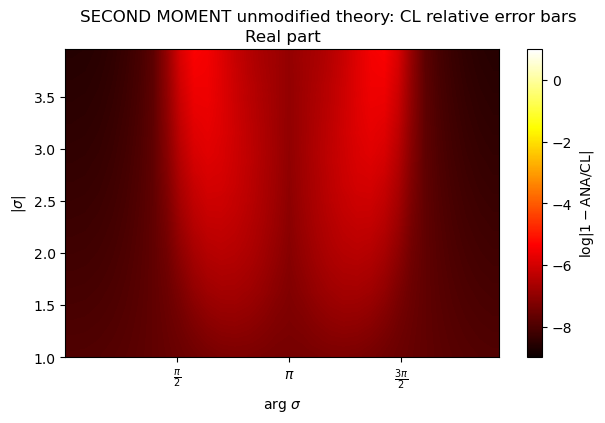

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Extract unique sigma_abs and sigma_phase values
sigma_abs_values = np.sort(df["sigma_abs"].unique())
sigma_phase_values = np.sort(df["sigma_phase"].unique())

# Reshape the data into a 2D array

fig, axes = plt.subplots(1, figsize=(7, 4), sharex = True, sharey = True) 

# Create the plot
# axes.figure(figsize=(8, 6))
extent=[sigma_phase_values.min(), sigma_phase_values.max(), sigma_abs_values.min(), sigma_abs_values.max()]
Z = df.pivot(index="sigma_abs", columns="sigma_phase", values="2_moment_sem").to_numpy()
im = axes.imshow(np.log(Z), aspect="auto", extent=extent, origin="lower", cmap="hot", interpolation= 'bilinear', vmin=-9, vmax=1)
fig.colorbar(im, label=r"$\log|1-\text{ANA}/\text{CL}|$")

axes.set_xlabel(r"arg $\sigma$")
axes.set_ylabel(r"$|\sigma|$")
axes.set_xticks([np.pi/2, np.pi, 3/2*np.pi])
axes.set_xticklabels([rf"$\frac{{\pi}}{{2}}$", rf"$\pi$" , rf"$\frac{{3\pi}}{{2}}$"])
fig.suptitle("SECOND MOMENT unmodified theory: CL relative error bars")

axes.set_title("Real part")

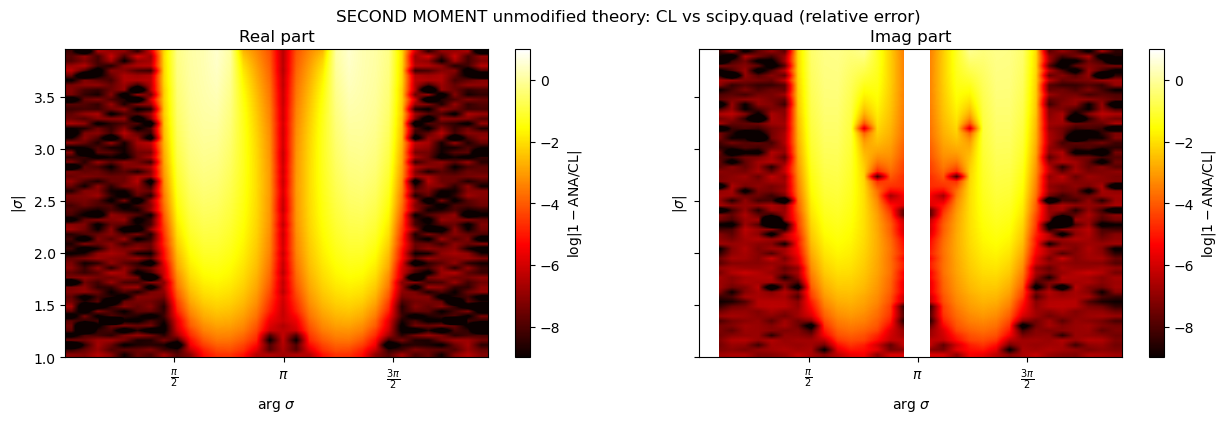

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Extract unique sigma_abs and sigma_phase values
sigma_abs_values = np.sort(df["sigma_abs"].unique())
sigma_phase_values = np.sort(df["sigma_phase"].unique())

# Reshape the data into a 2D array

fig, axes = plt.subplots(1,2, figsize=(15, 4), sharex = True, sharey = True) 

# Create the plot
# axes.figure(figsize=(8, 6))
extent=[sigma_phase_values.min(), sigma_phase_values.max(), sigma_abs_values.min(), sigma_abs_values.max()]
Z = df.pivot(index="sigma_abs", columns="sigma_phase", values="2_moment_mean_real_clerror").to_numpy()
im = axes[0].imshow(np.log(Z), aspect="auto", extent=extent, origin="lower", cmap="hot", vmin=-9, vmax=1, interpolation= 'bilinear')
fig.colorbar(im, label=r"$\log|1-\text{ANA}/\text{CL}|$")

Z = df.pivot(index="sigma_abs", columns="sigma_phase", values="2_moment_mean_imag_clerror").to_numpy()
im = axes[1].imshow(np.log(Z), aspect="auto", extent=extent, origin="lower", cmap="hot", vmin=-9, vmax=1, interpolation= 'bilinear')
fig.colorbar(im, ax=axes[1], label=r"$\log|1-\text{ANA}/\text{CL}|$")

# plt.hlines(np.pi/2, xmin=sigma_abs_values.min(), xmax=sigma_abs_values.max())
# plt.hlines(3*np.pi/2, xmin=sigma_abs_values.min(), xmax=sigma_abs_values.max())

axes[0].set_xlabel(r"arg $\sigma$")
axes[0].set_ylabel(r"$|\sigma|$")
axes[1].set_xlabel(r"arg $\sigma$")
axes[1].set_ylabel(r"$|\sigma|$")
axes[0].set_xticks([np.pi/2, np.pi, 3/2*np.pi])
axes[0].set_xticklabels([rf"$\frac{{\pi}}{{2}}$", rf"$\pi$" , rf"$\frac{{3\pi}}{{2}}$"])
fig.suptitle("SECOND MOMENT unmodified theory: CL vs scipy.quad (relative error)")

axes[0].set_title("Real part")
axes[1].set_title("Imag part")

plt.savefig("ASDF")

In [ ]:
import scienceplots
# plt.style.use('science')

for sigma_abs, sigma_abs_group in df.groupby("sigma_abs"):
    if True:
        fig, axes = plt.subplots(2, 2, figsize=(15, 6), sharex = True) 
        axes = axes.flatten()
        fig.suptitle(rf"$\rho = \exp{{(-S)}}$  $|\sigma| = {{{sigma_abs}}}$")

        sigma_phase_ana = np.linspace(0, 2*np.pi, 128)
        sigma_ana = sigma_abs * np.exp(1j*sigma_phase_ana)

        axes[0].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["2_moment_mean_real"],yerr=sigma_abs_group["2_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2, label = "CL")
        axes[2].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["4_moment_mean_real"],yerr=sigma_abs_group["4_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2, label = "CL")
        axes[1].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["2_moment_mean_imag"],yerr=sigma_abs_group["2_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2)
        axes[3].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["4_moment_mean_imag"],yerr=sigma_abs_group["4_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2)
        
        ana = n_moment_expval_unmod(2, sigma_ana, 1)
        axes[0].plot(sigma_phase_ana, np.real(ana), color = "red", label = "scipy")
        axes[1].plot(sigma_phase_ana, np.imag(ana), color = "red", label = "scipy")

        ana = n_moment_expval_unmod(4, sigma_ana, 1)
        axes[2].plot(sigma_phase_ana, np.real(ana), color = "blue", label = "scipy")
        axes[3].plot(sigma_phase_ana, np.imag(ana), color = "blue", label = "scipy")

        axes[0].set_title("real part")
        axes[1].set_title("imag part")

        axes[0].legend()
        axes[1].legend()
        axes[2].legend()
        axes[3].legend()

        axes[2].set_xlabel(rf"arg $\sigma$")
        axes[3].set_xlabel(rf"arg $\sigma$")
        axes[0].set_ylabel(rf"$\langle z^2 \rangle$")
        axes[2].set_ylabel(rf"$\langle z^4 \rangle$")
        ylim = ax.get_ylim()
        for ax in axes: 
            ylim = ax.get_ylim()
            ax.vlines(np.pi/2, *ylim, ls="--")
            ax.vlines(3*np.pi/2, *ylim, ls="--")
        

/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_20334/2523097350.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(15, 6), sharex = True)


1.0: max imag rel err: inf
1.046875: max imag rel err: inf
1.09375: max imag rel err: inf
1.140625: max imag rel err: inf
1.1875: max imag rel err: inf
1.234375: max imag rel err: inf
1.28125: max imag rel err: inf
1.328125: max imag rel err: inf
1.375: max imag rel err: inf
1.421875: max imag rel err: inf
1.46875: max imag rel err: inf
1.515625: max imag rel err: inf
1.5625: max imag rel err: inf
1.609375: max imag rel err: inf
1.65625: max imag rel err: inf
1.703125: max imag rel err: inf
1.75: max imag rel err: inf
1.796875: max imag rel err: inf
1.84375: max imag rel err: inf
1.890625: max imag rel err: inf


/var/folders/d1/h9d5k7zx0c7555qbjvw2ck240000gn/T/ipykernel_20334/3623258077.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(15, 6), sharex = True)


1.9375: max imag rel err: inf
1.984375: max imag rel err: inf
2.03125: max imag rel err: inf
2.078125: max imag rel err: inf
2.125: max imag rel err: inf
2.171875: max imag rel err: inf
2.21875: max imag rel err: inf
2.265625: max imag rel err: inf
2.3125: max imag rel err: inf
2.359375: max imag rel err: inf
2.40625: max imag rel err: inf
2.453125: max imag rel err: inf
2.5: max imag rel err: inf
2.546875: max imag rel err: inf
2.59375: max imag rel err: inf
2.640625: max imag rel err: inf
2.6875: max imag rel err: inf
2.734375: max imag rel err: inf
2.78125: max imag rel err: inf
2.828125: max imag rel err: inf
2.875: max imag rel err: inf
2.921875: max imag rel err: inf
2.96875: max imag rel err: inf
3.015625: max imag rel err: inf
3.0625: max imag rel err: inf
3.109375: max imag rel err: inf
3.15625: max imag rel err: inf
3.203125: max imag rel err: inf
3.25: max imag rel err: inf
3.296875: max imag rel err: inf
3.34375: max imag rel err: inf
3.390625: max imag rel err: inf
3.4375:

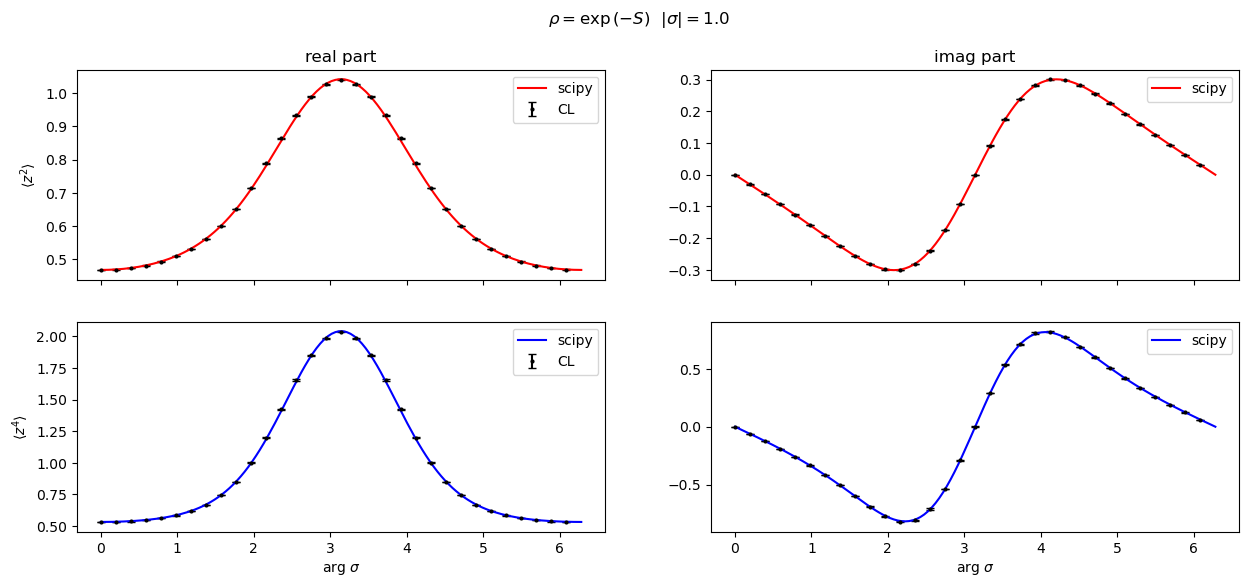

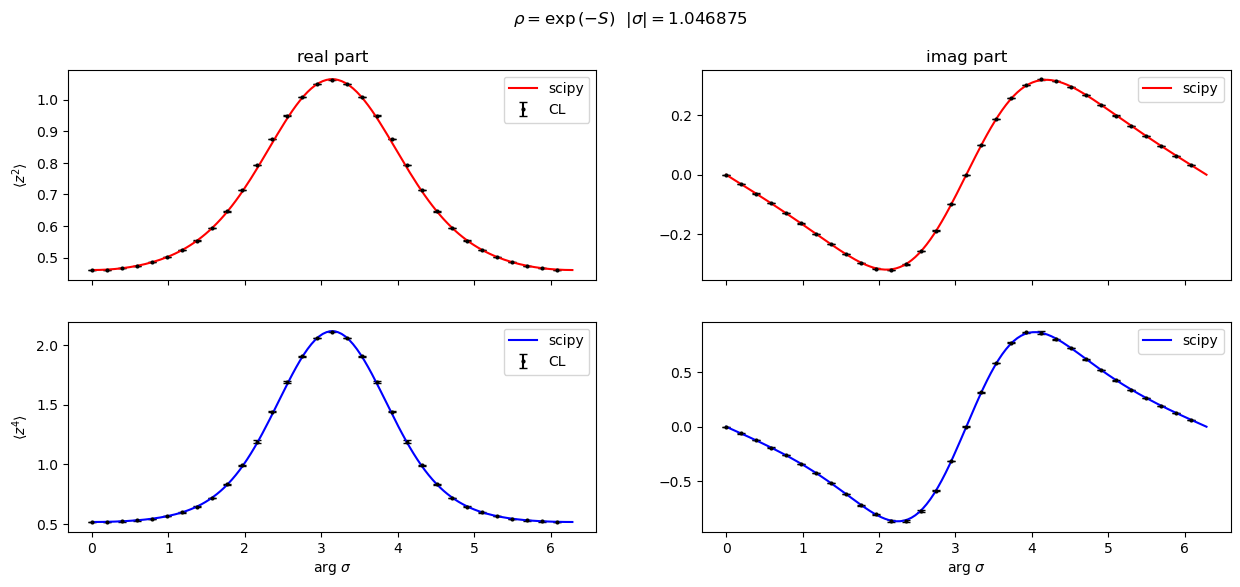

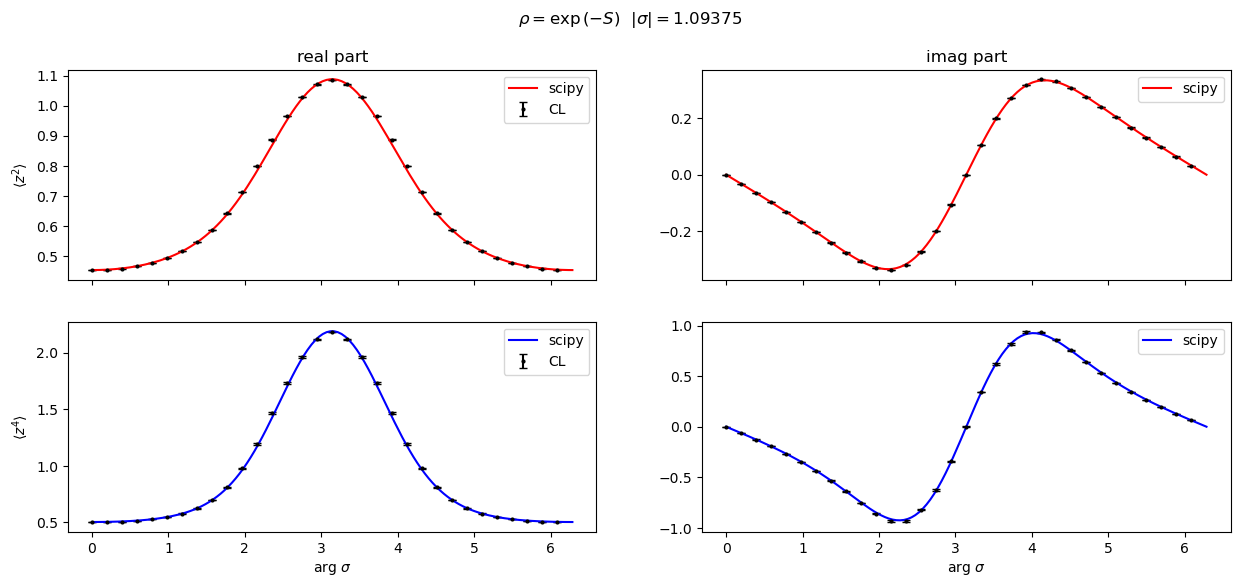

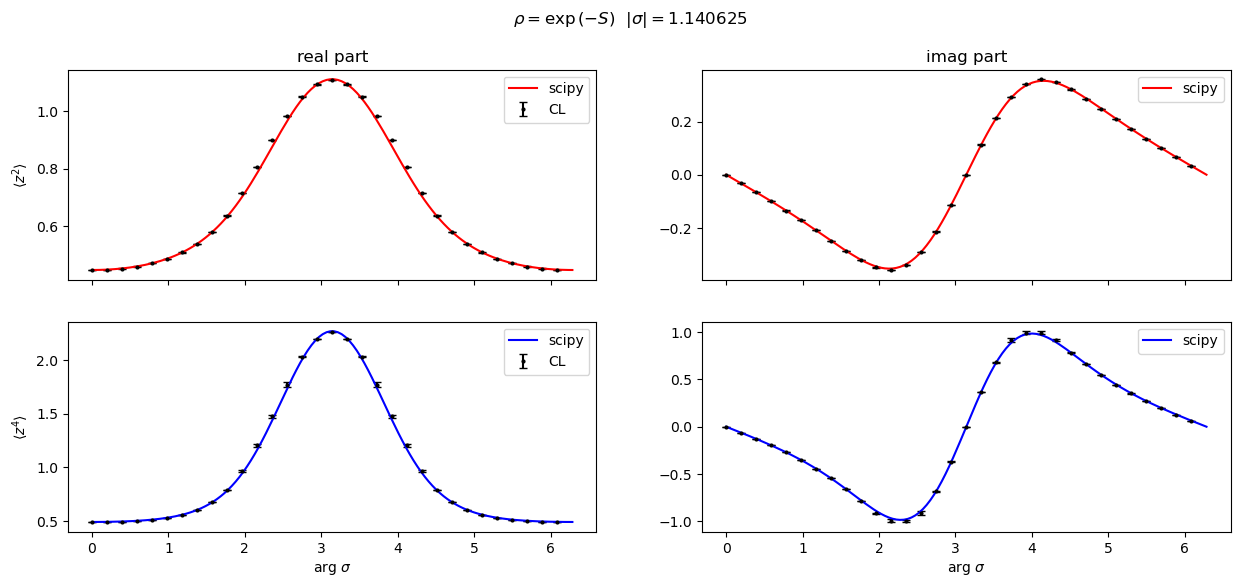

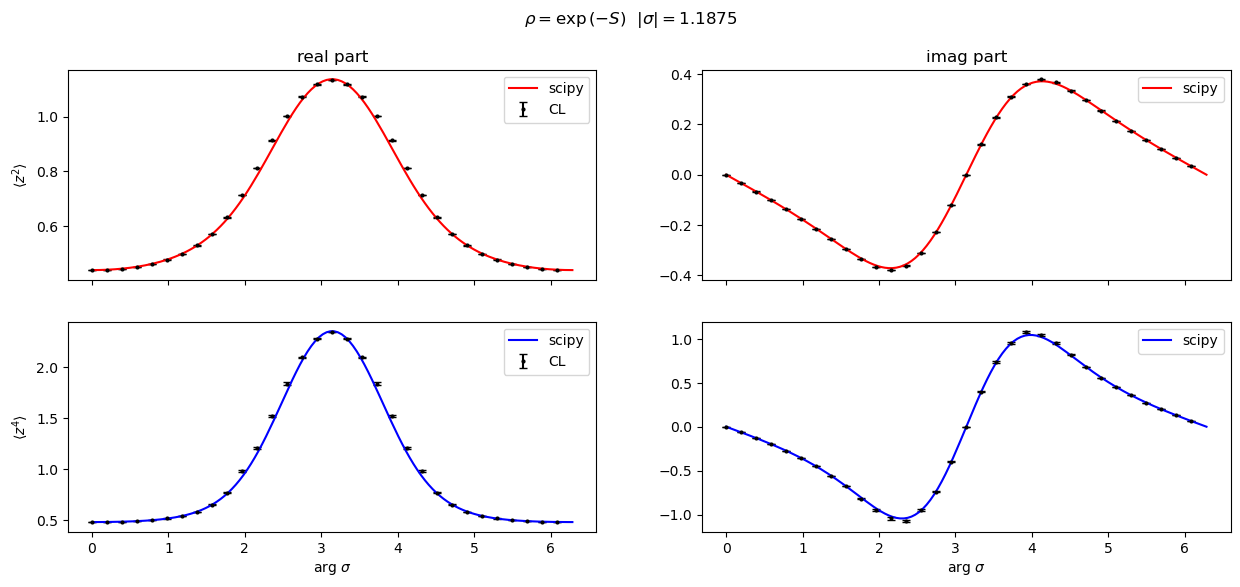

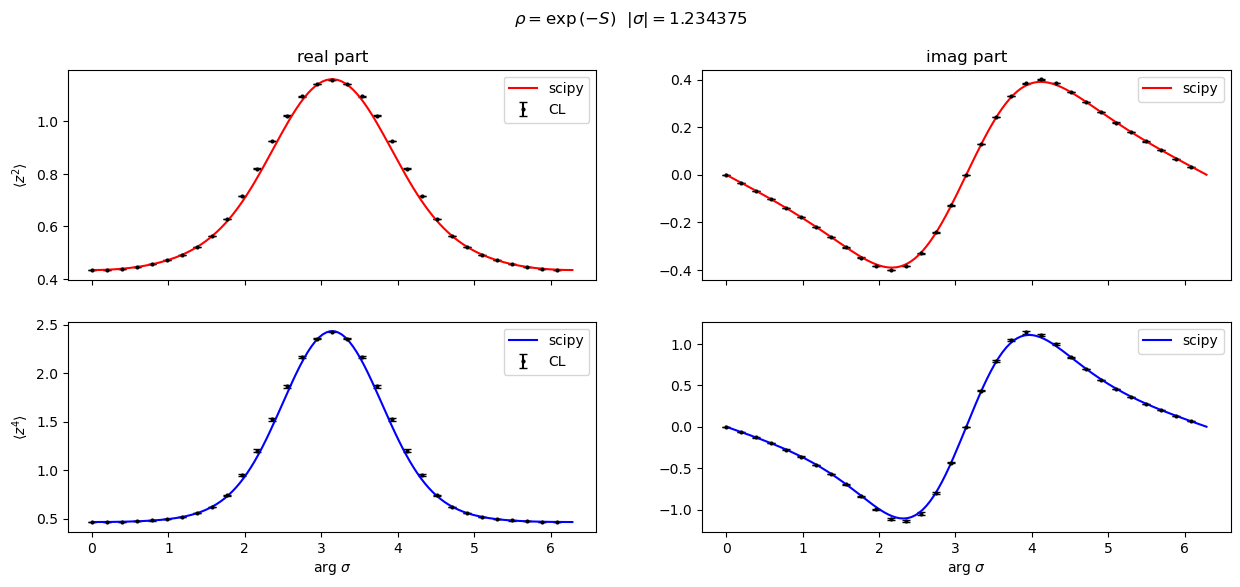

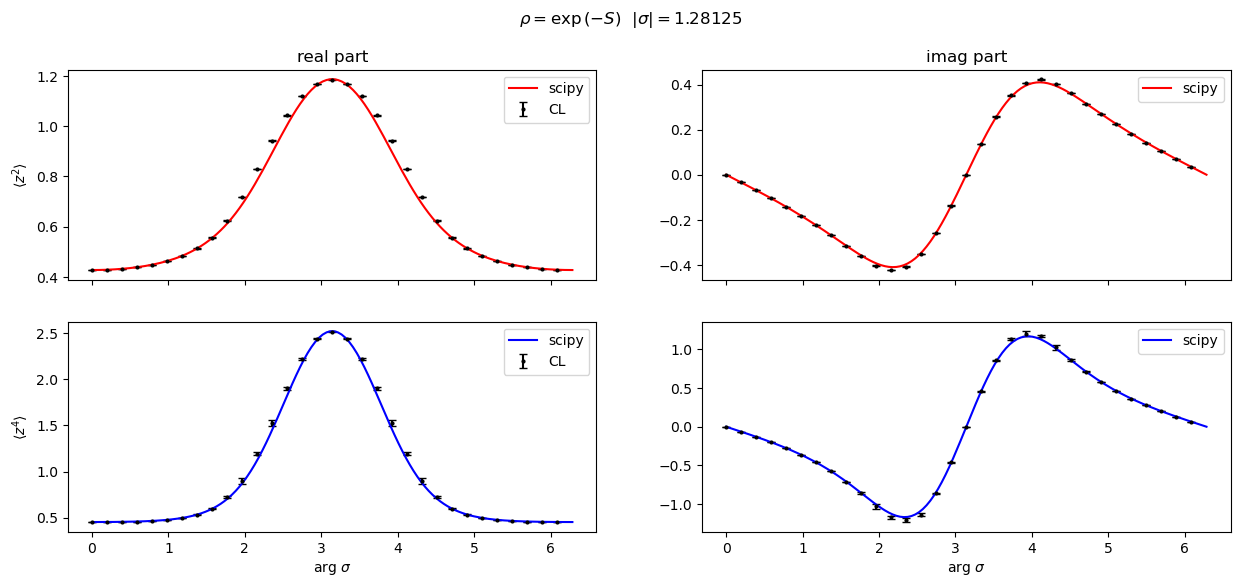

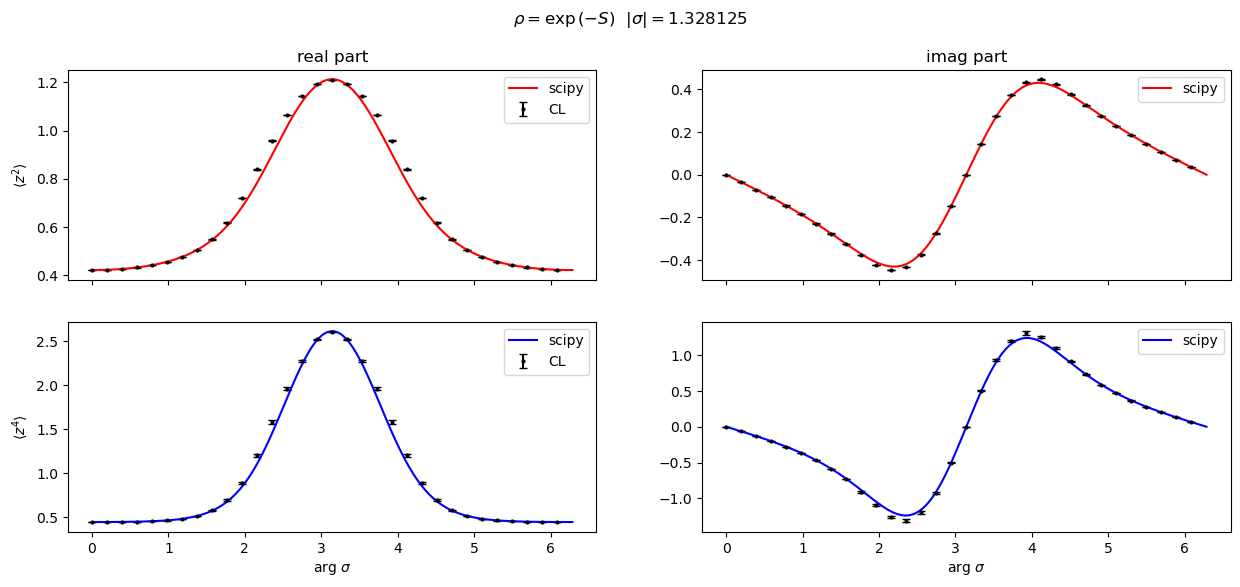

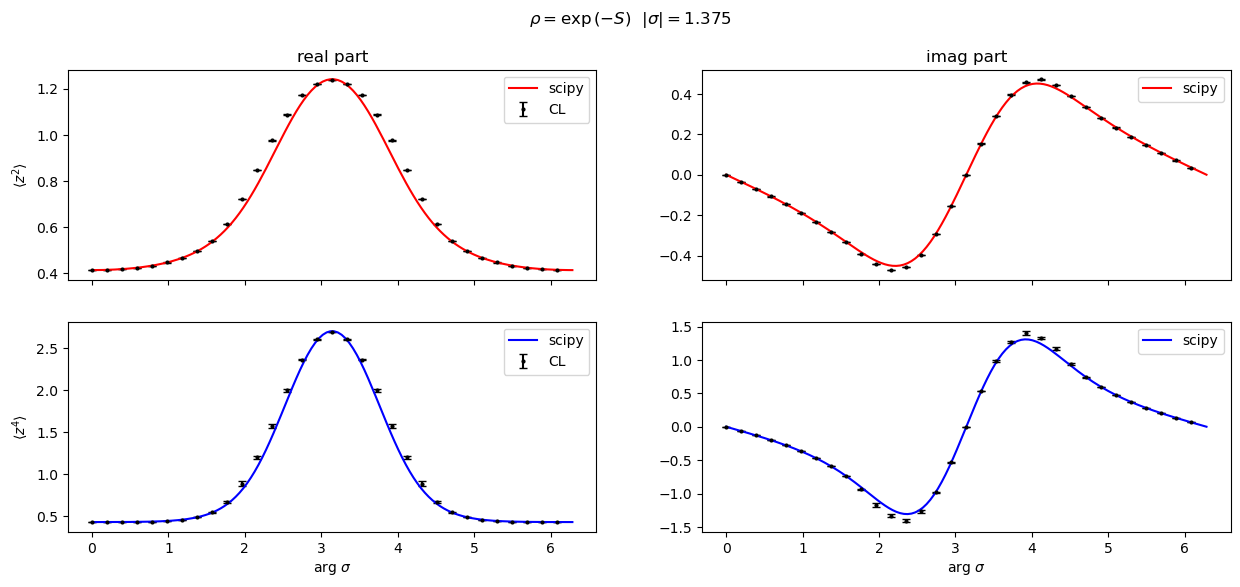

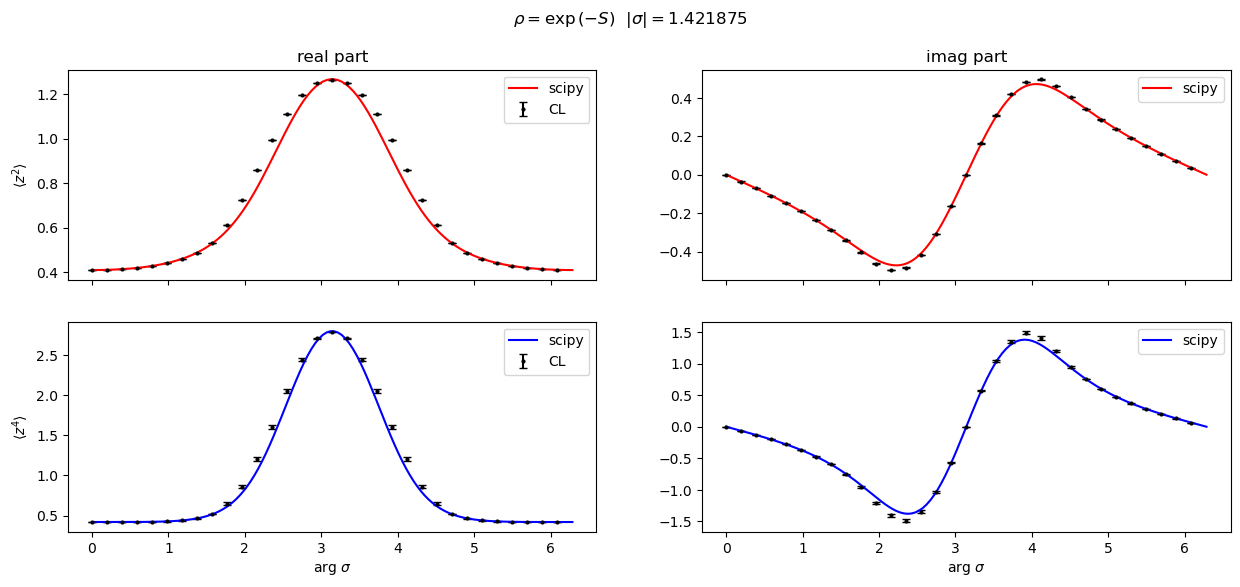

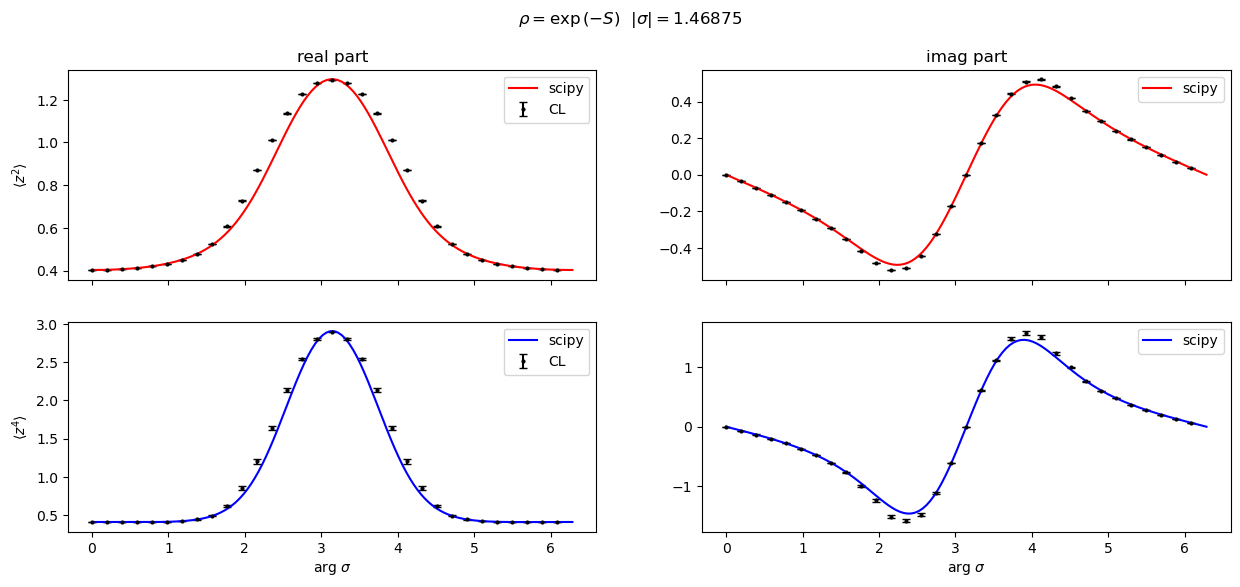

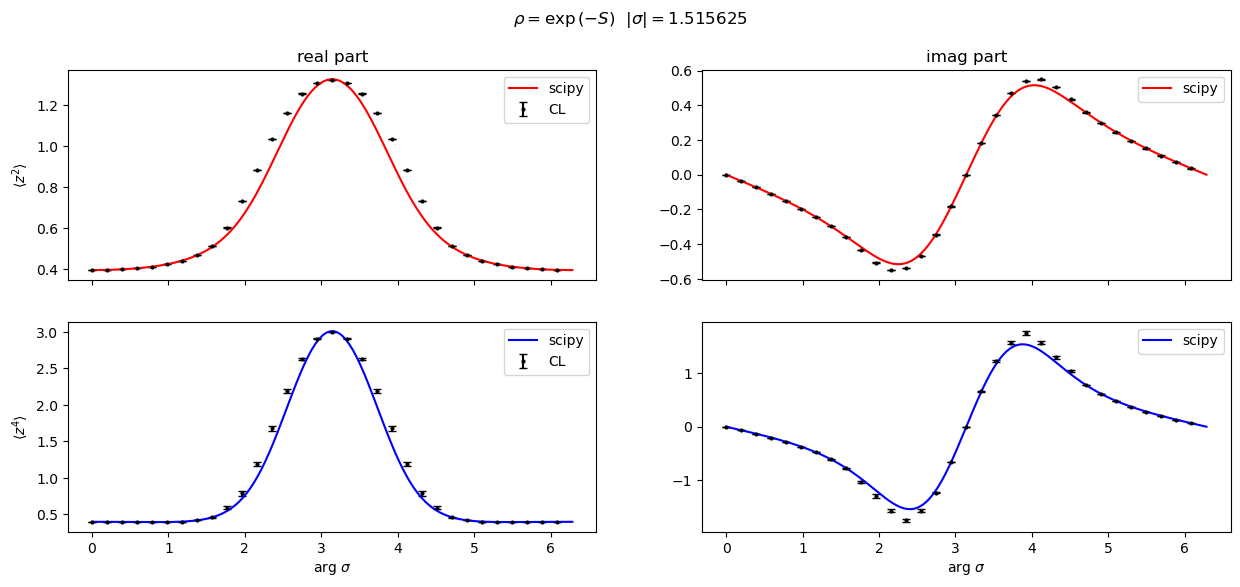

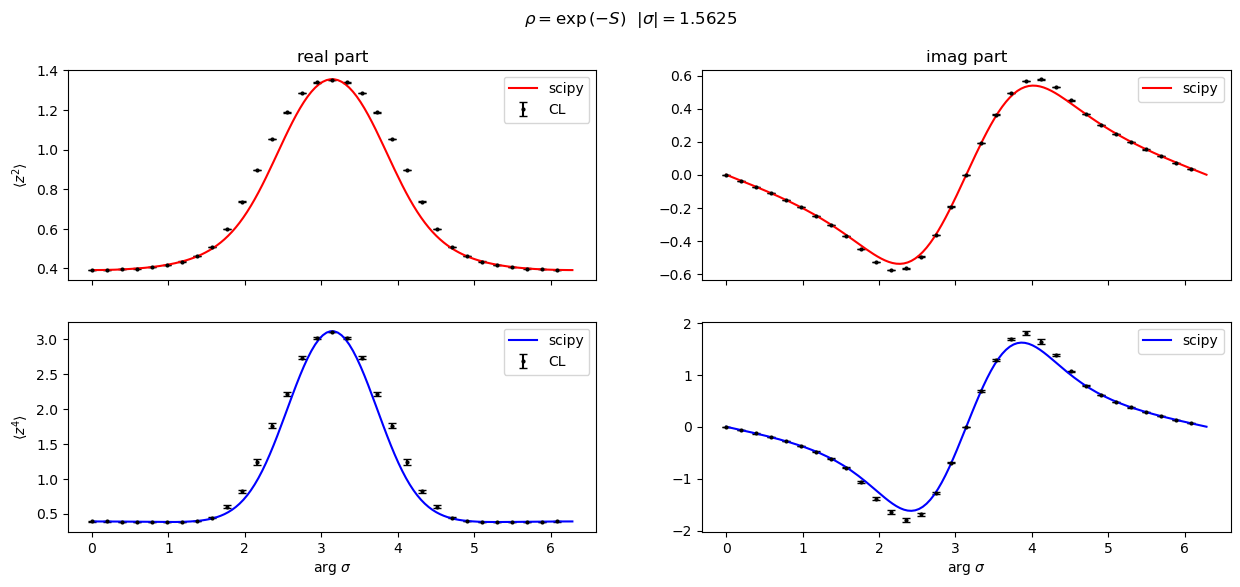

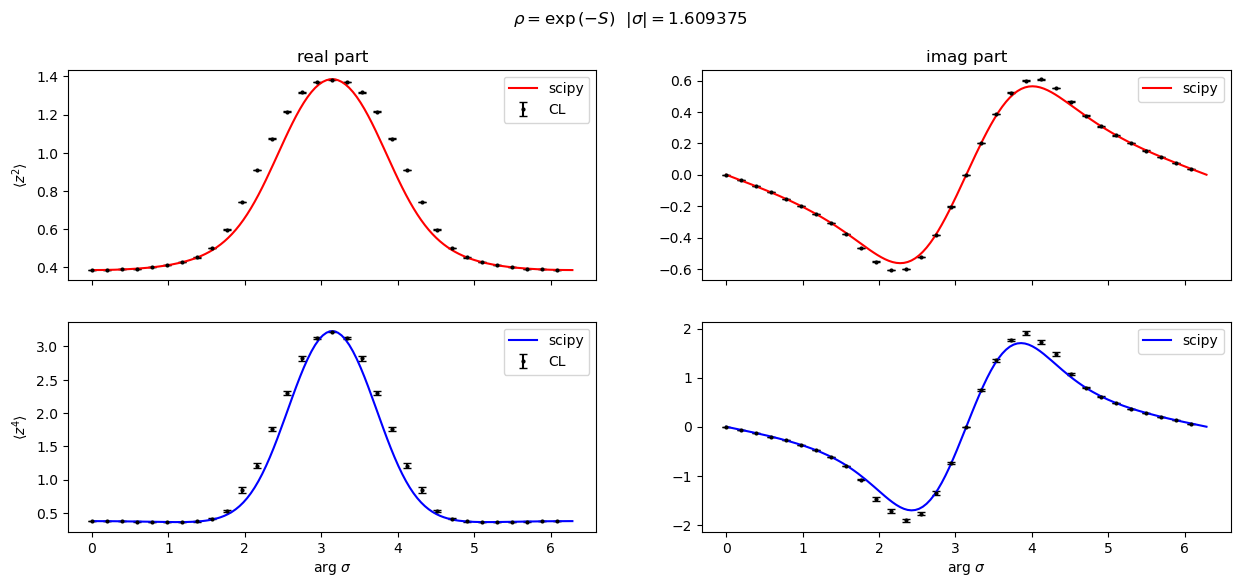

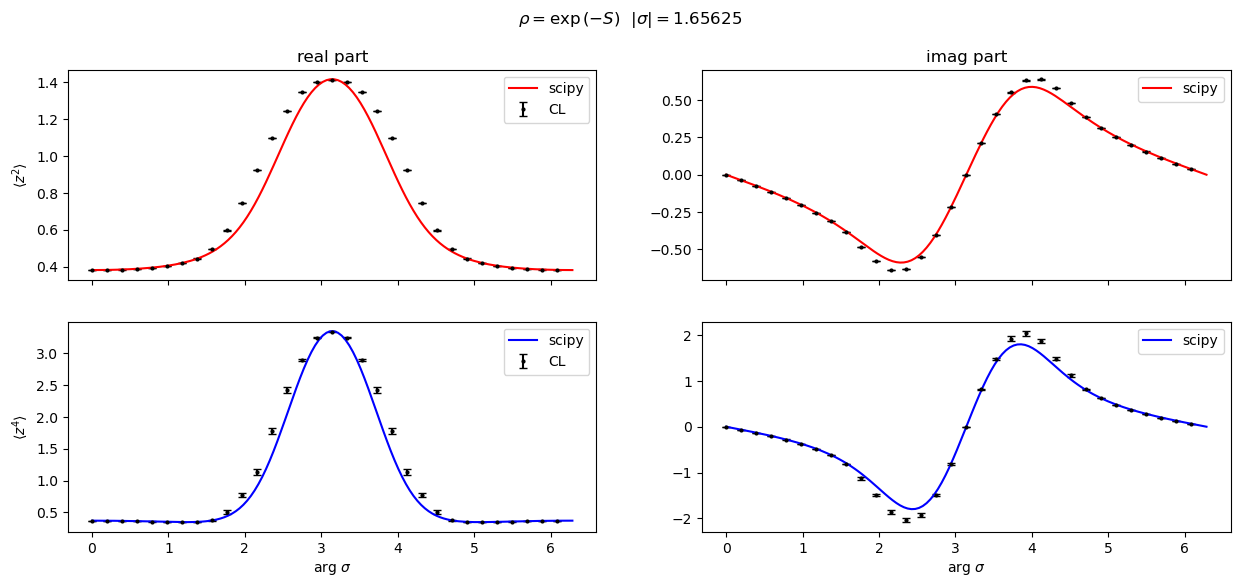

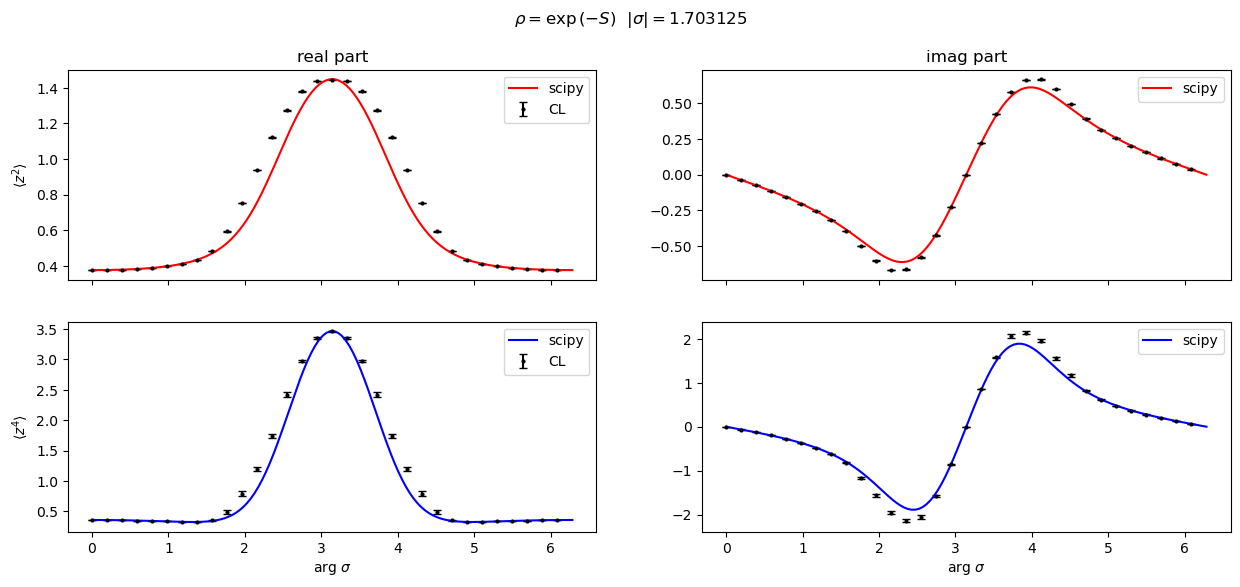

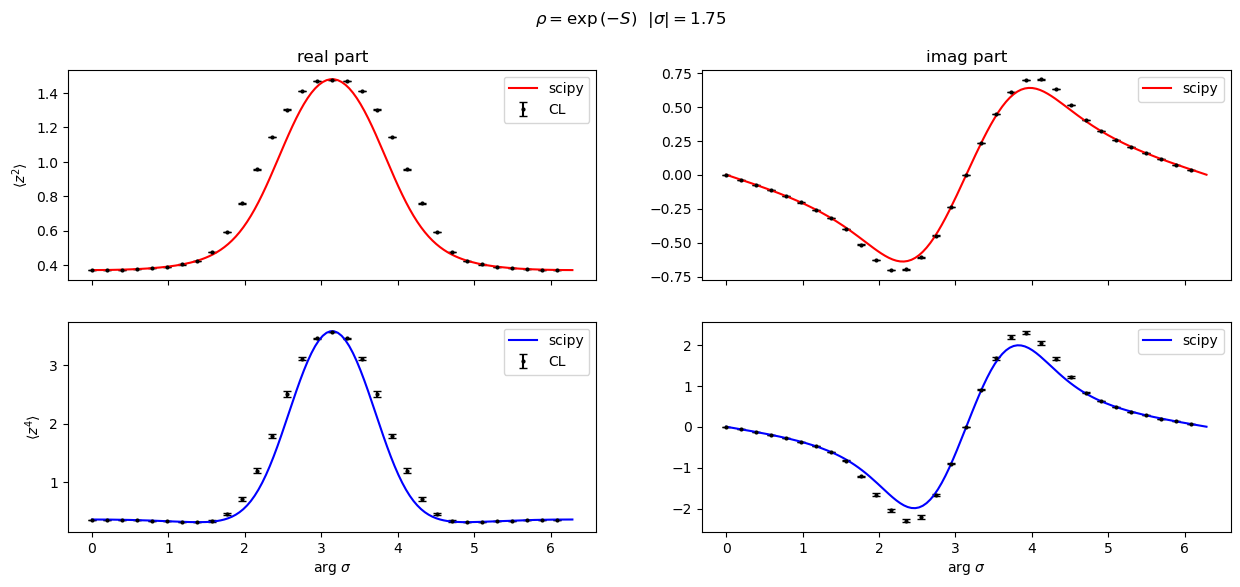

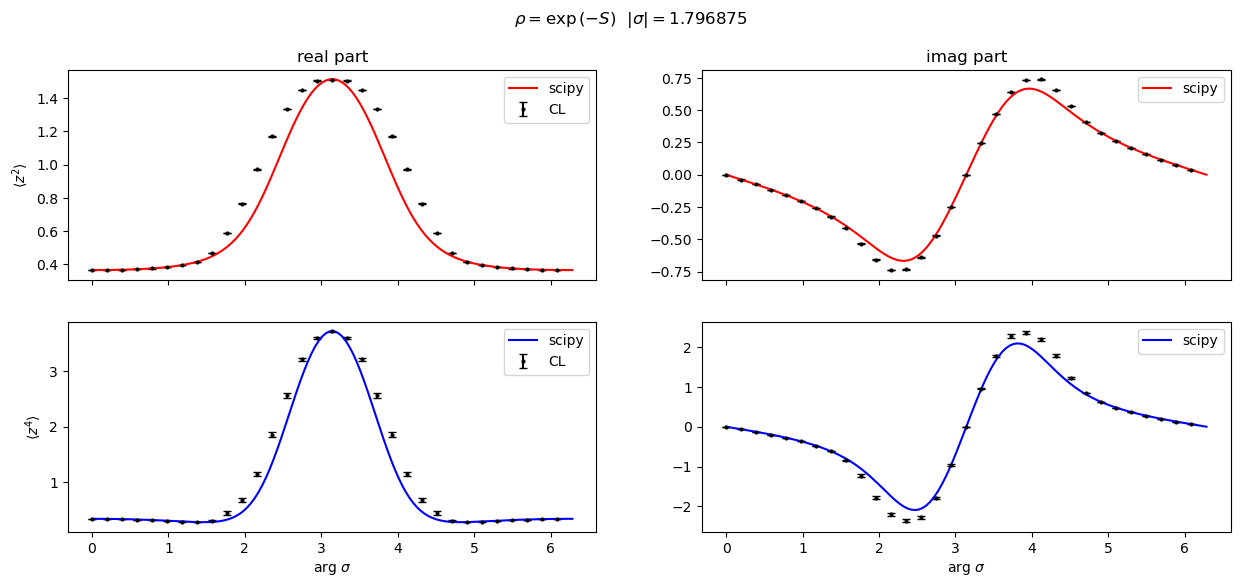

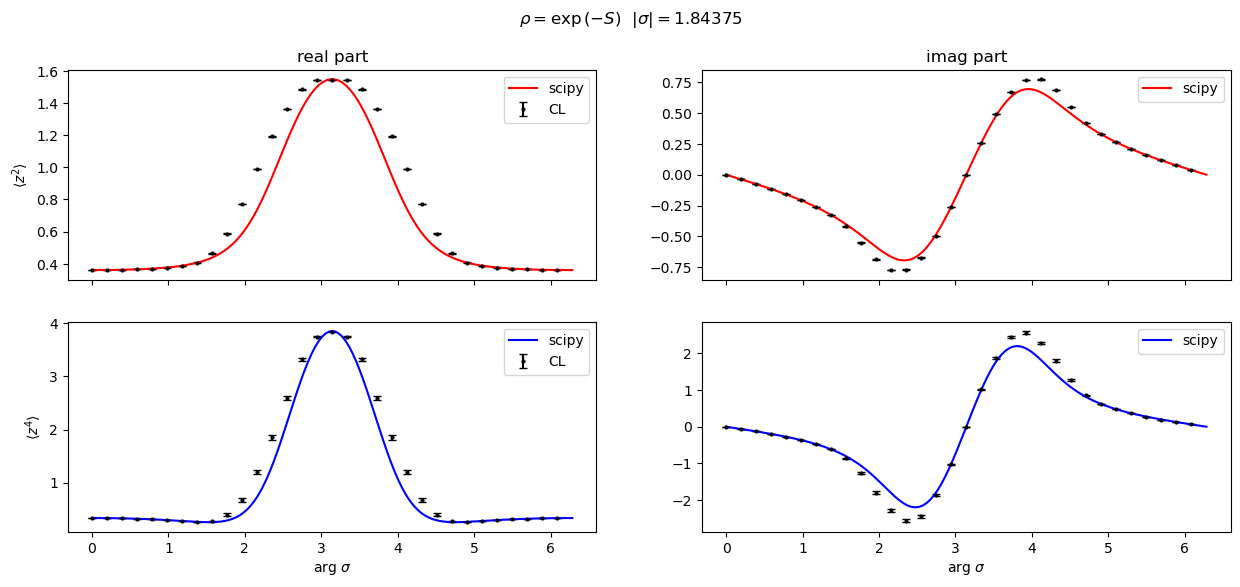

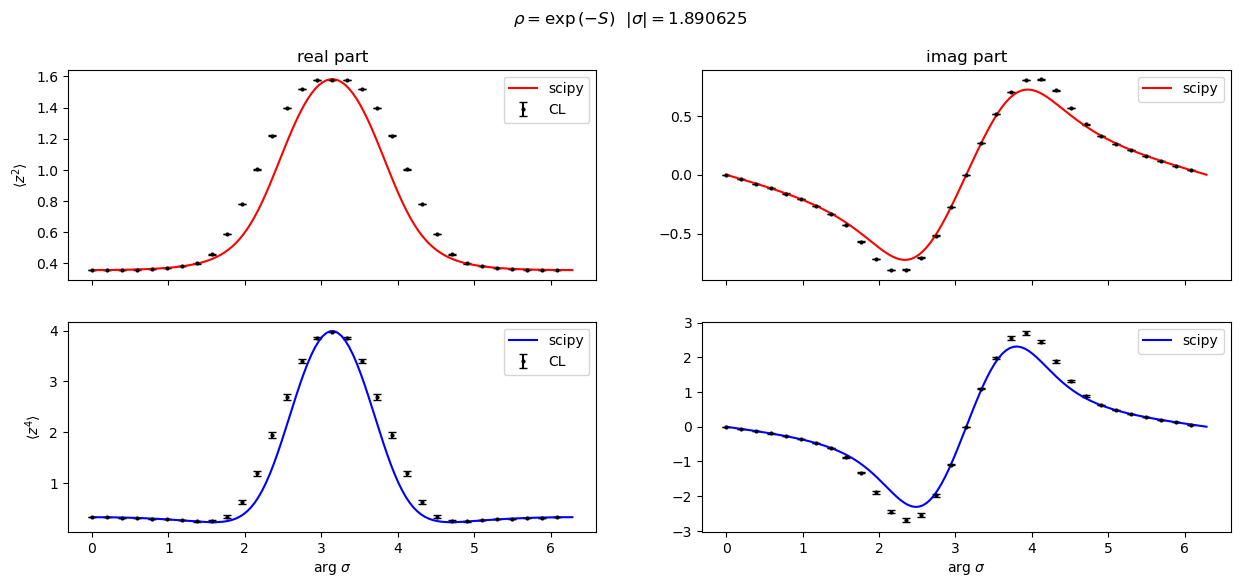

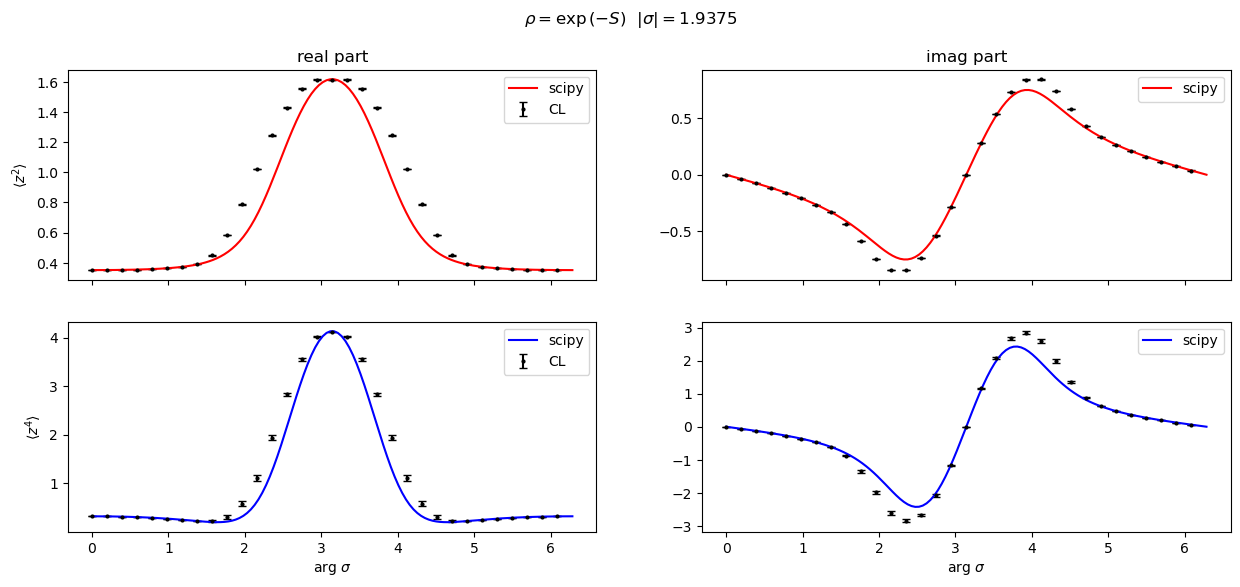

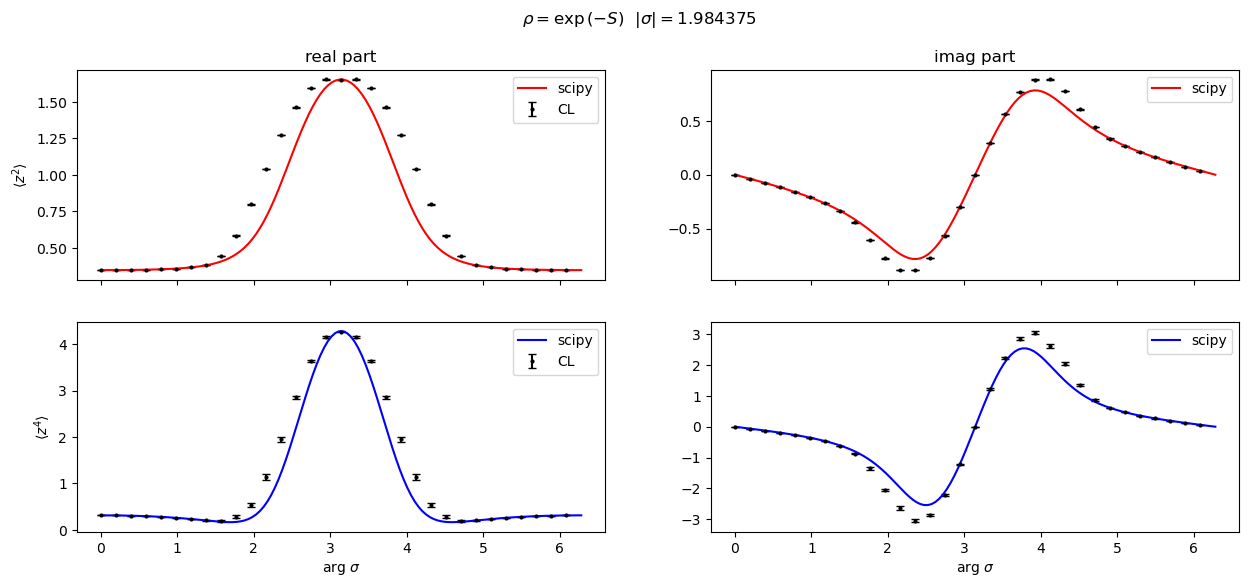

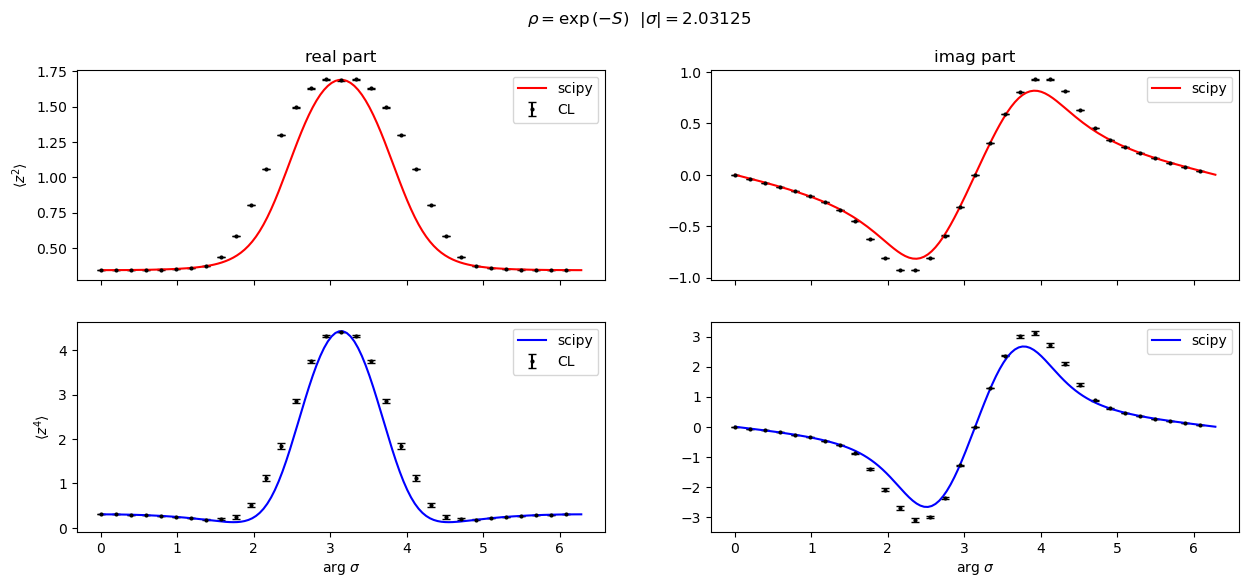

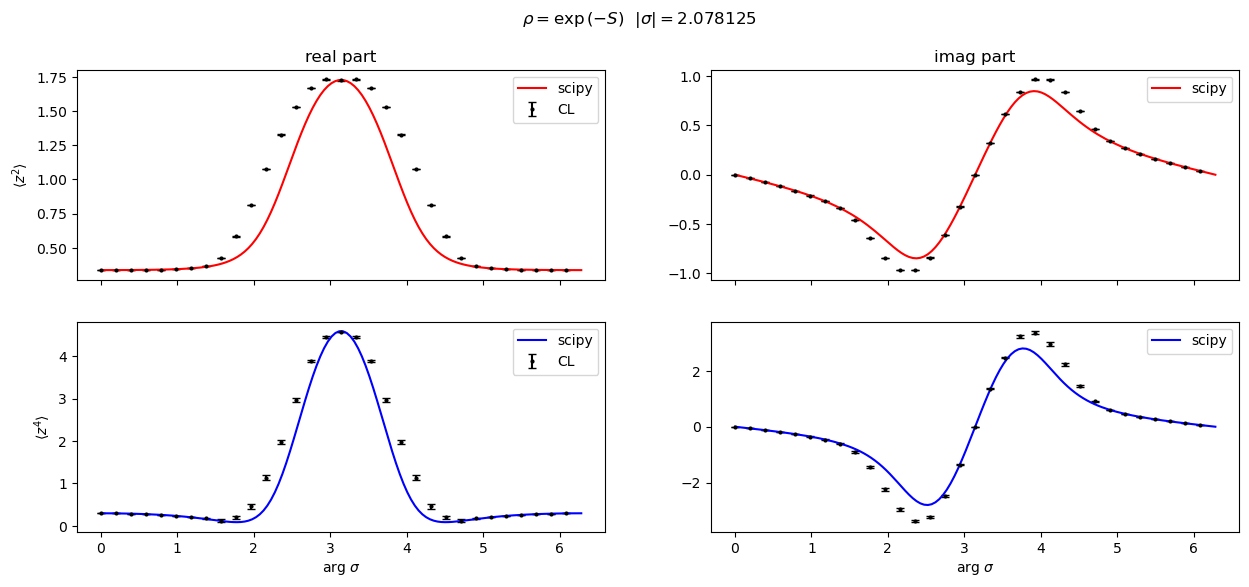

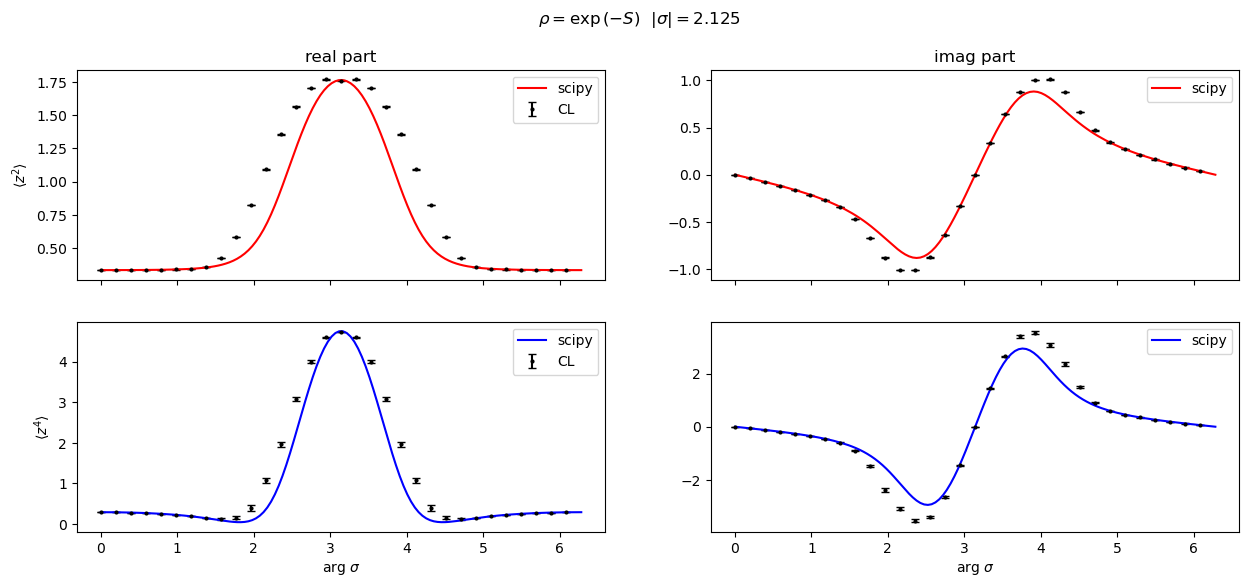

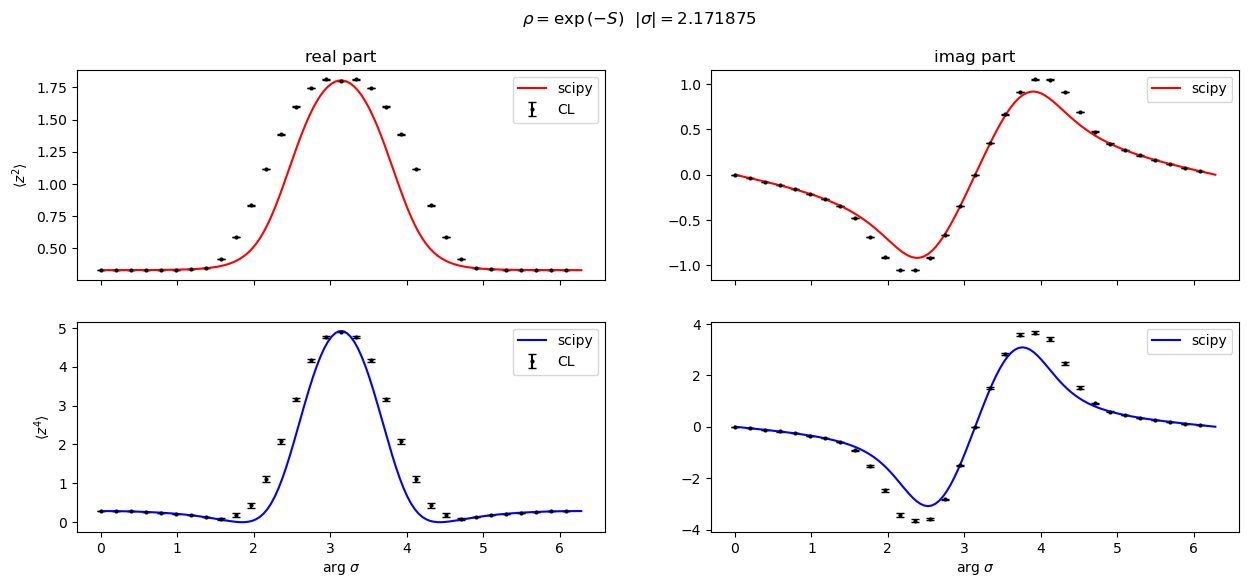

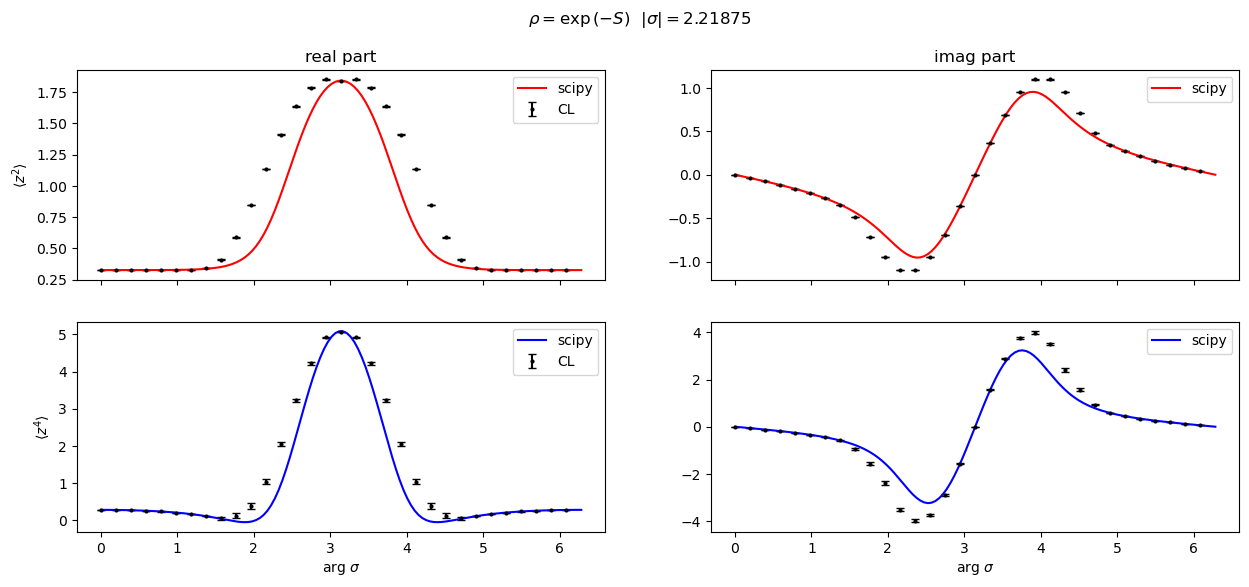

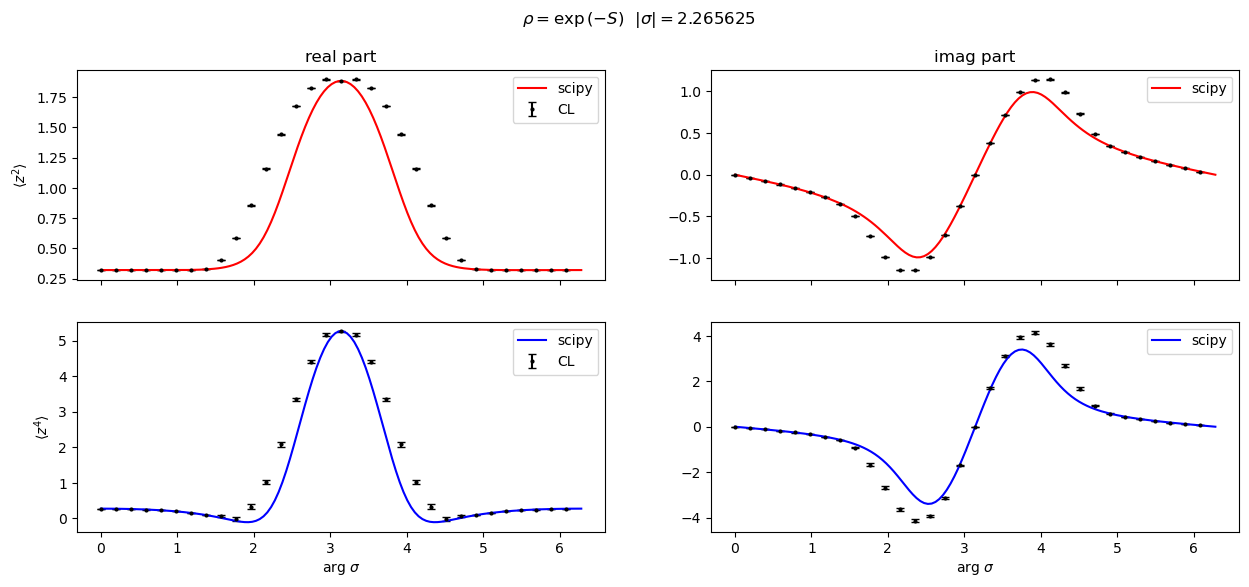

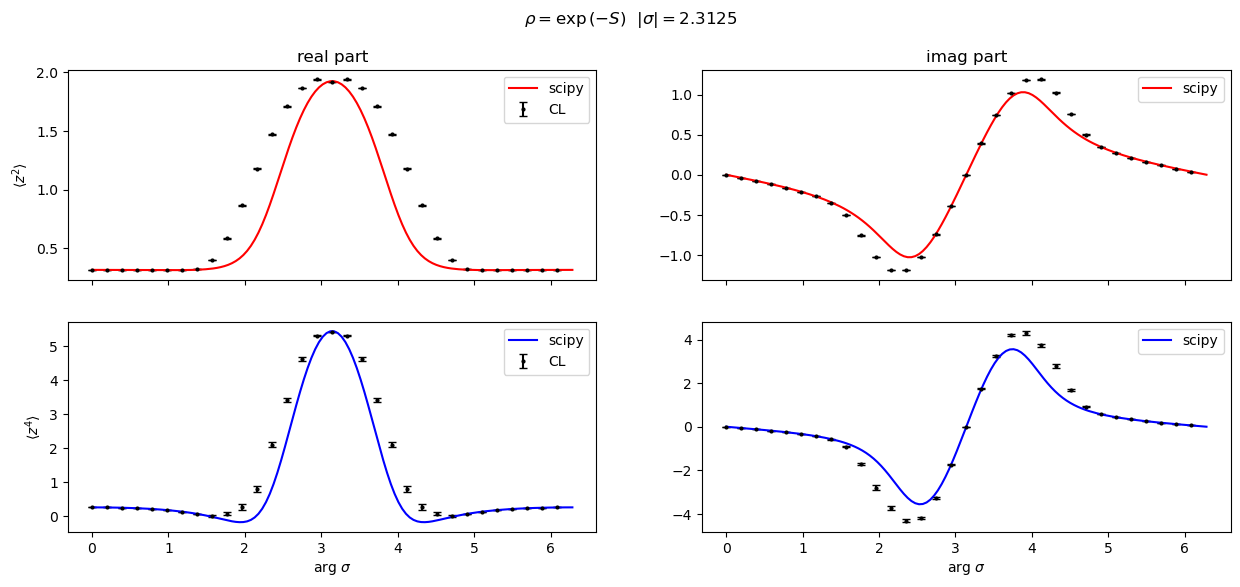

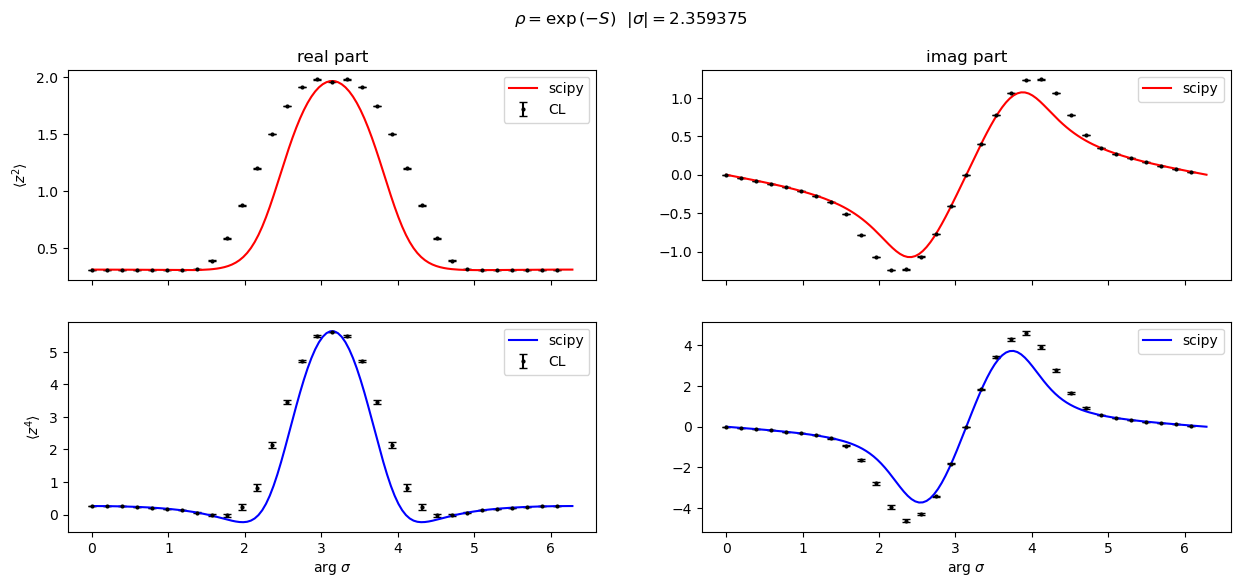

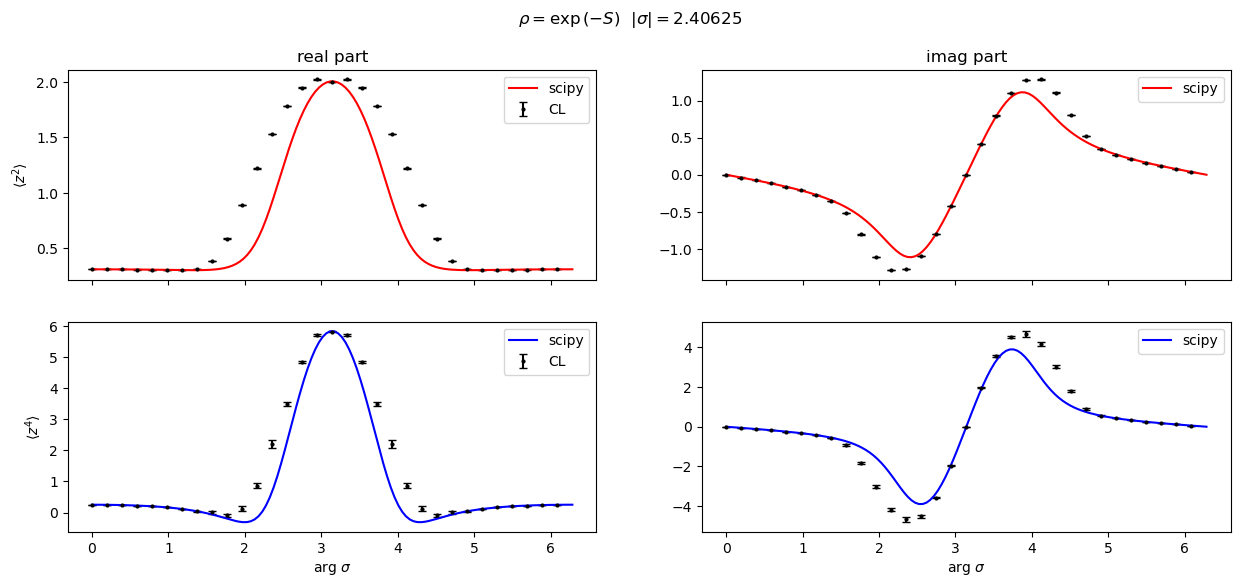

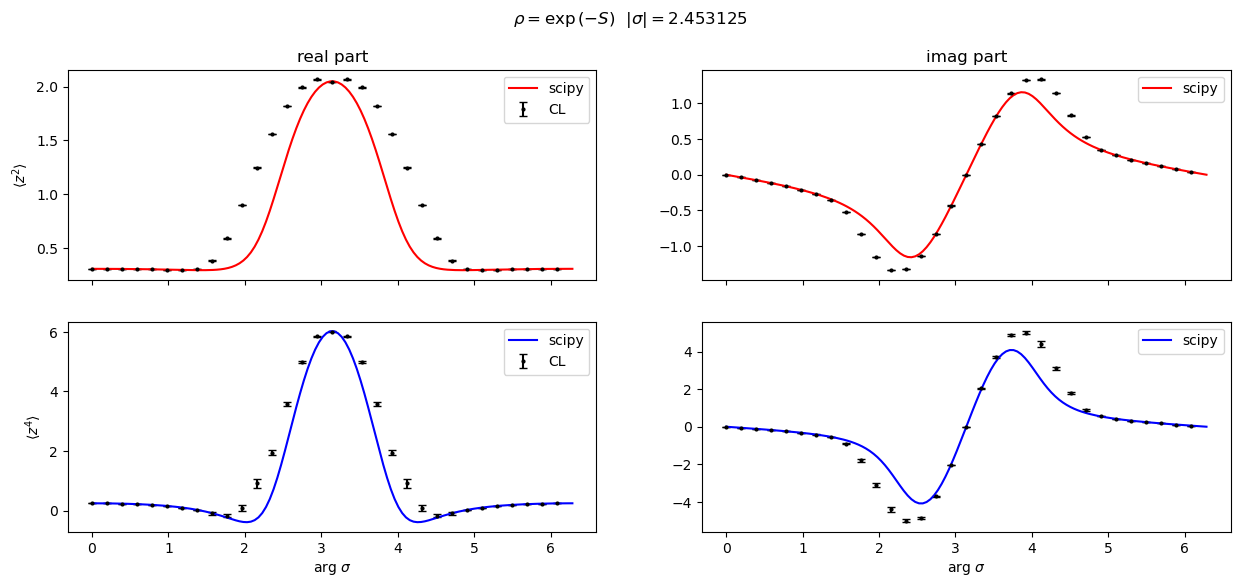

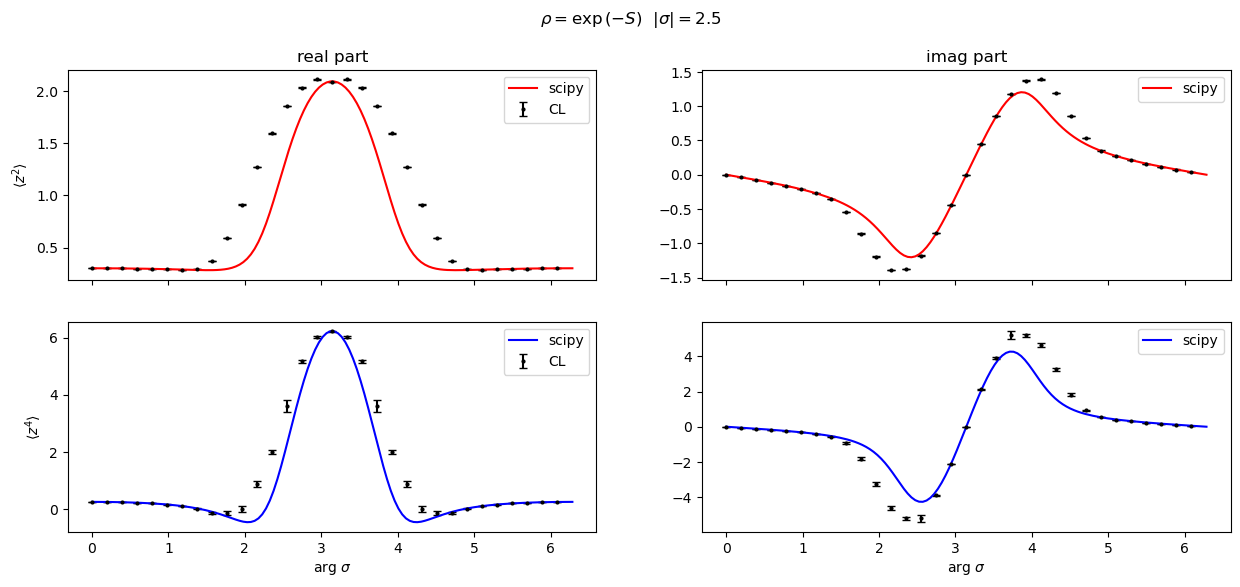

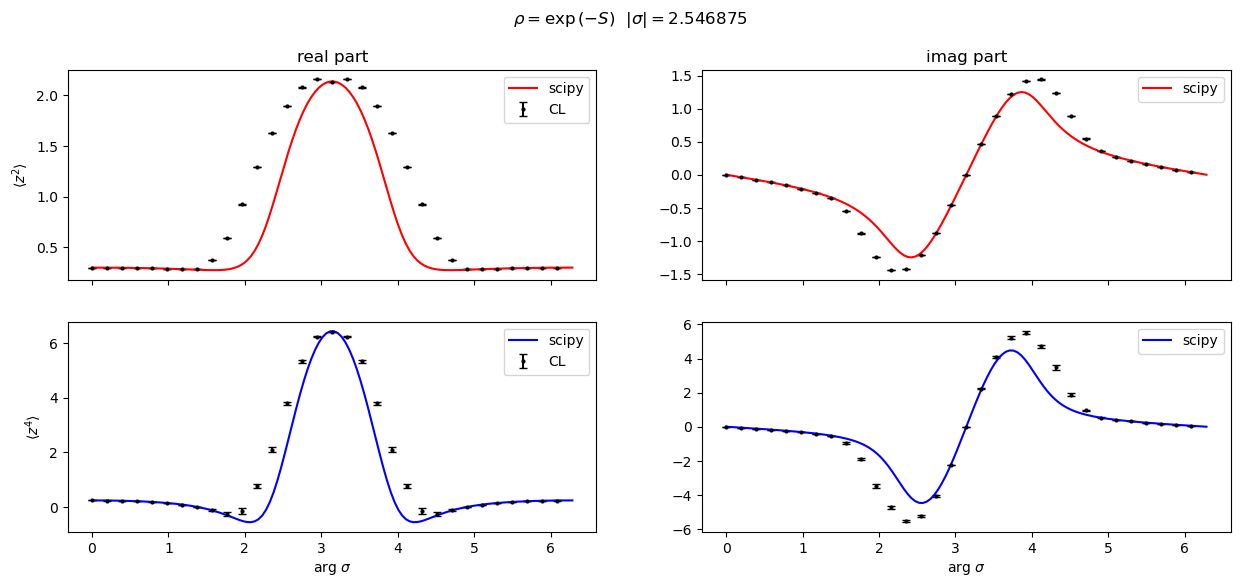

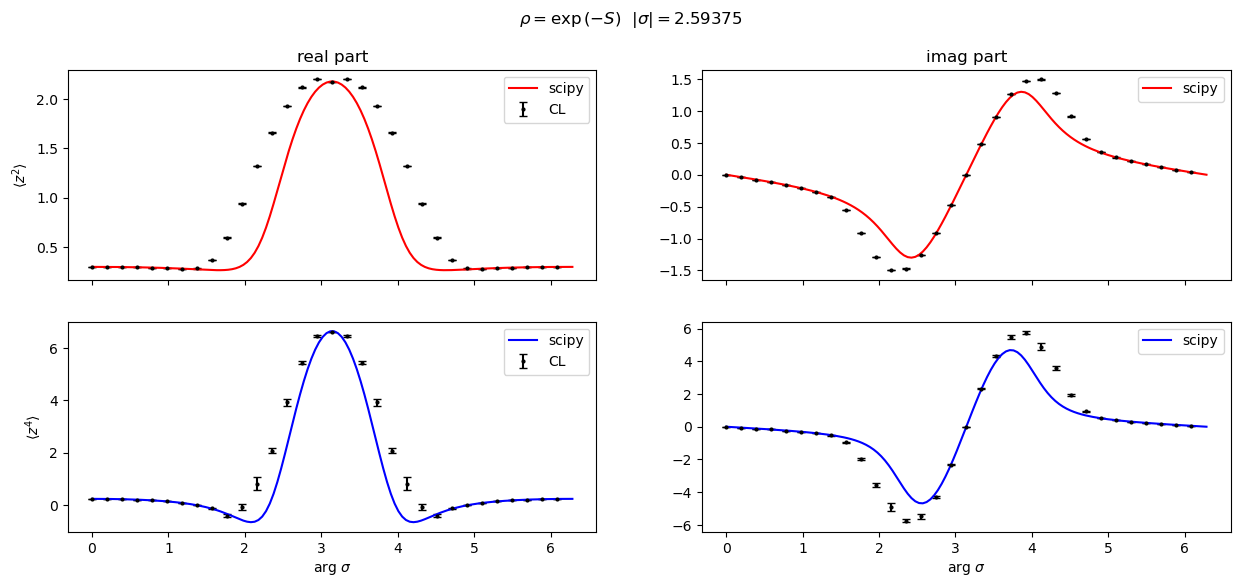

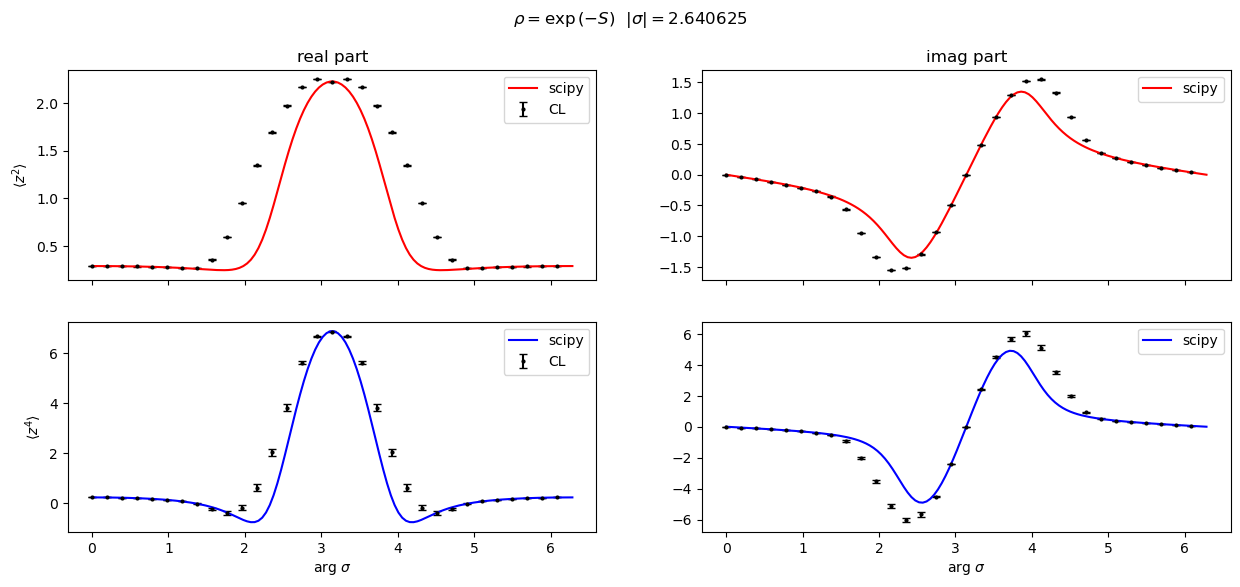

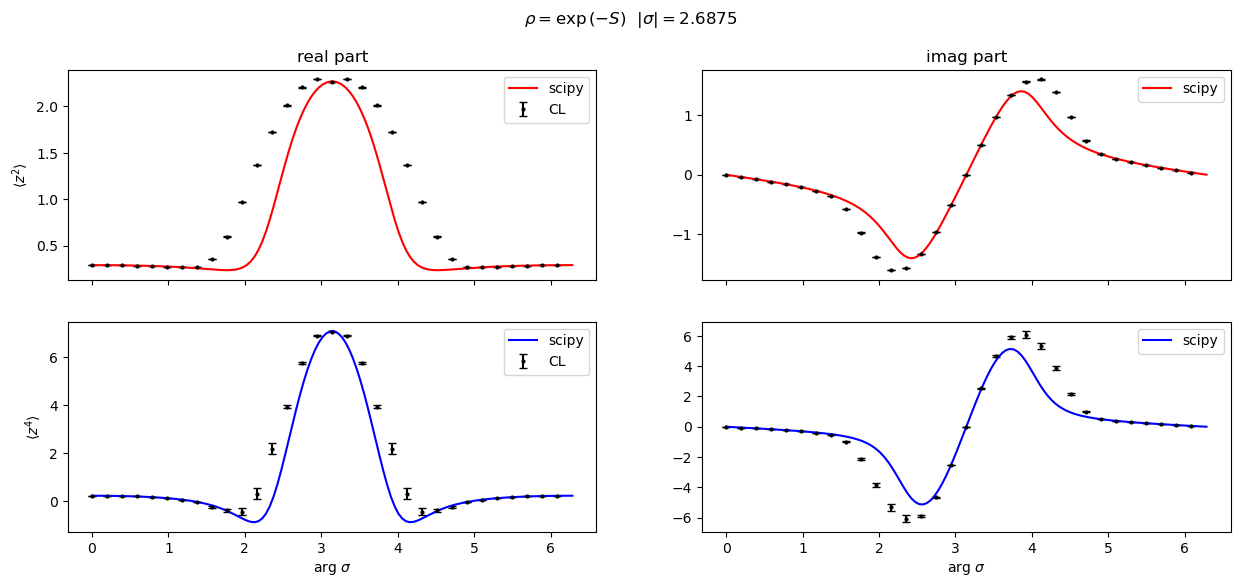

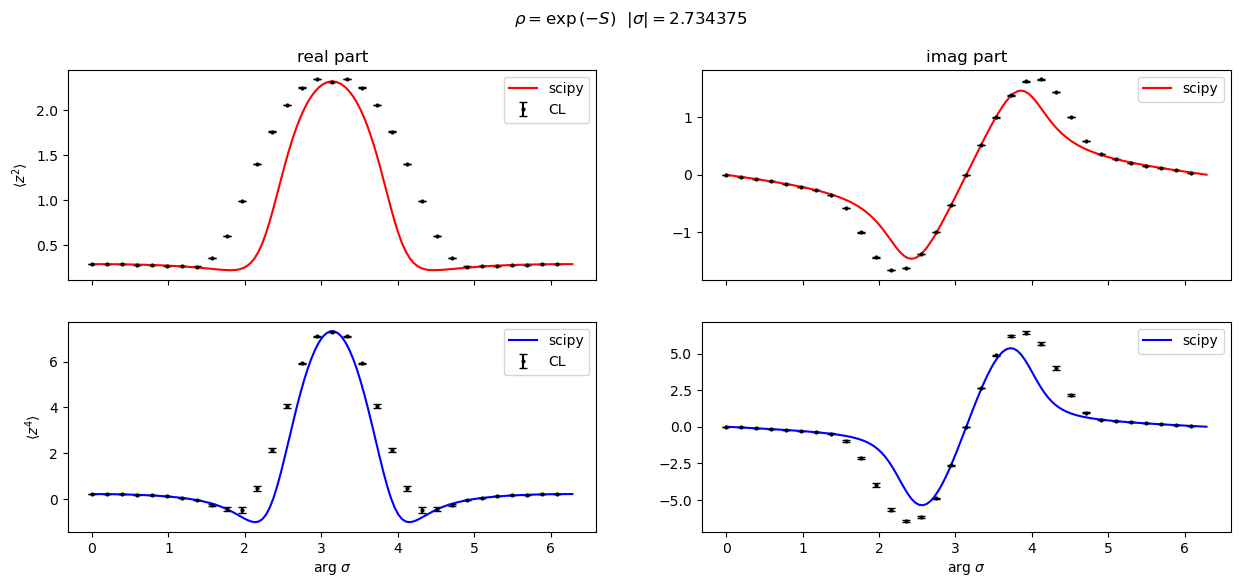

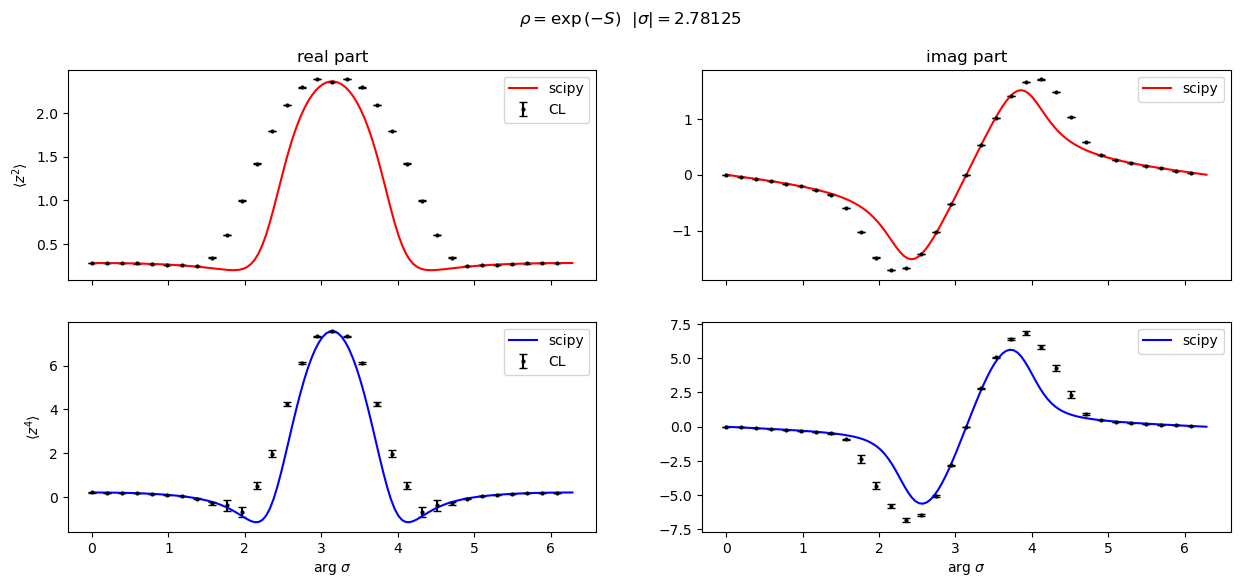

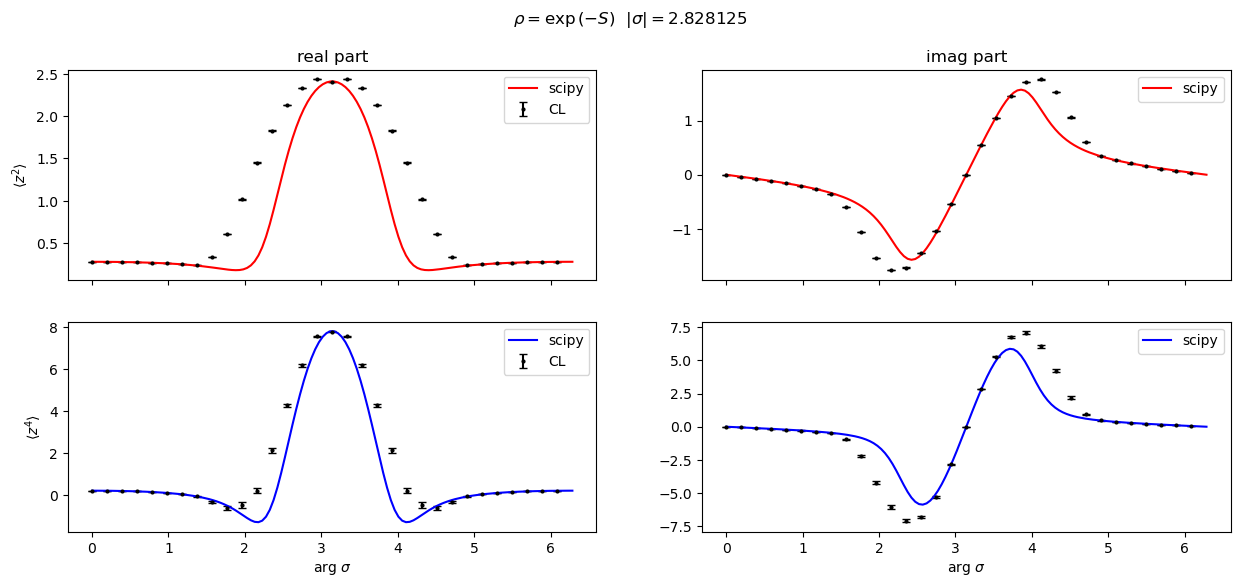

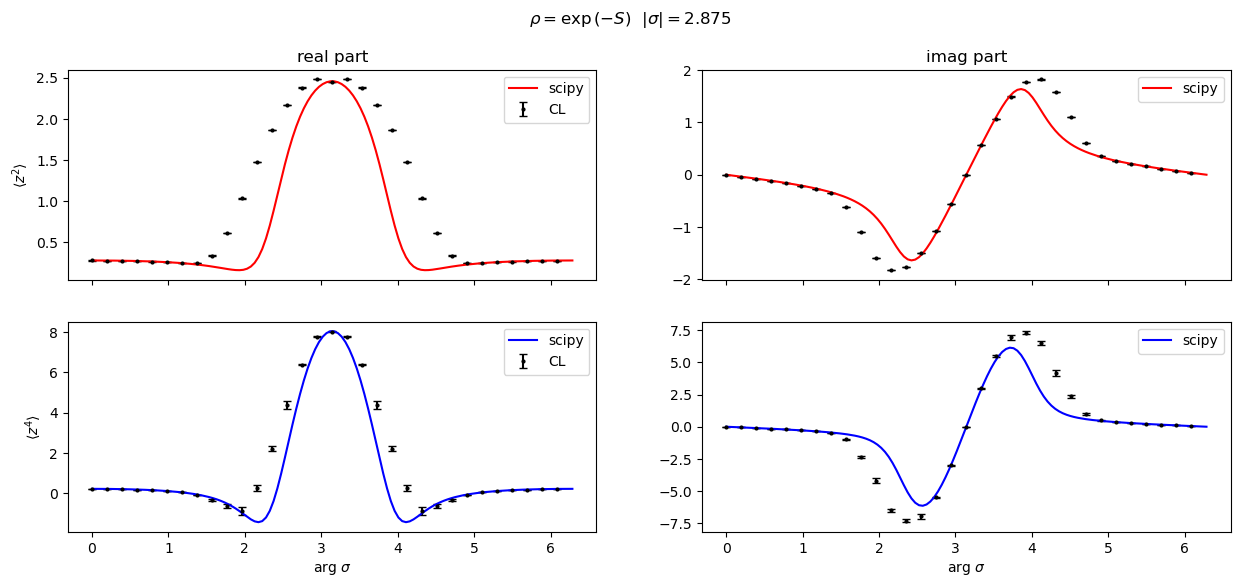

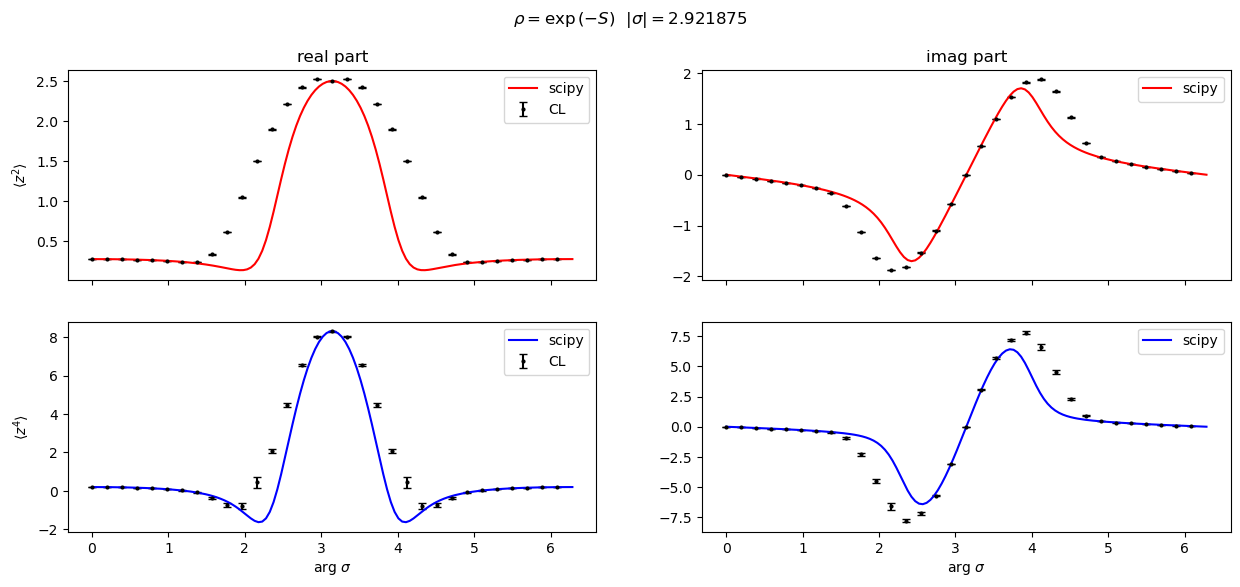

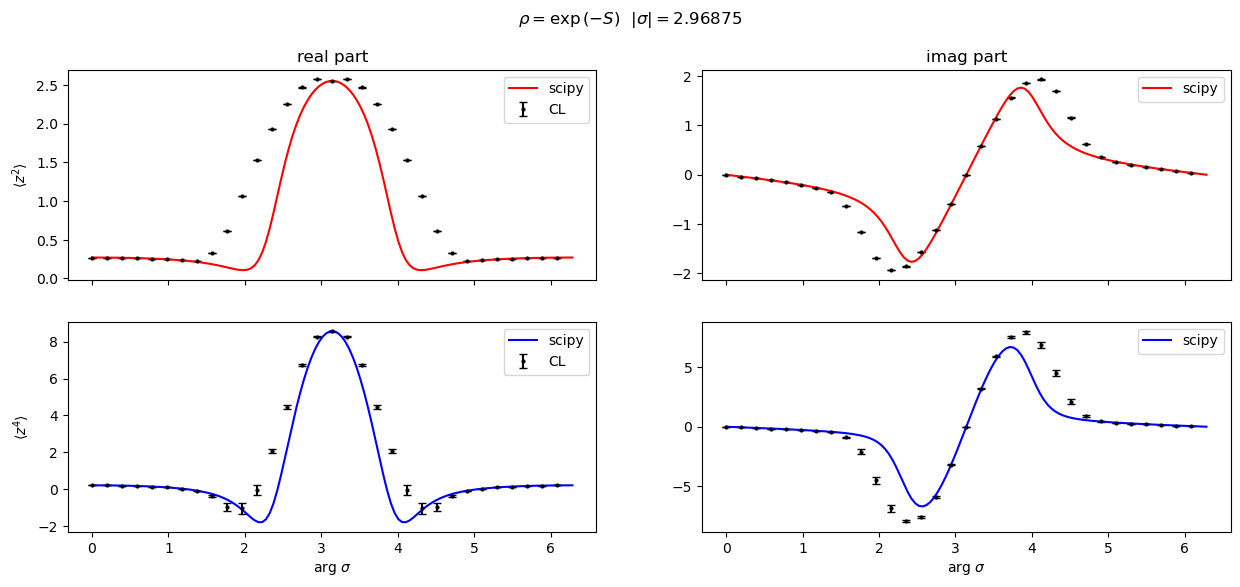

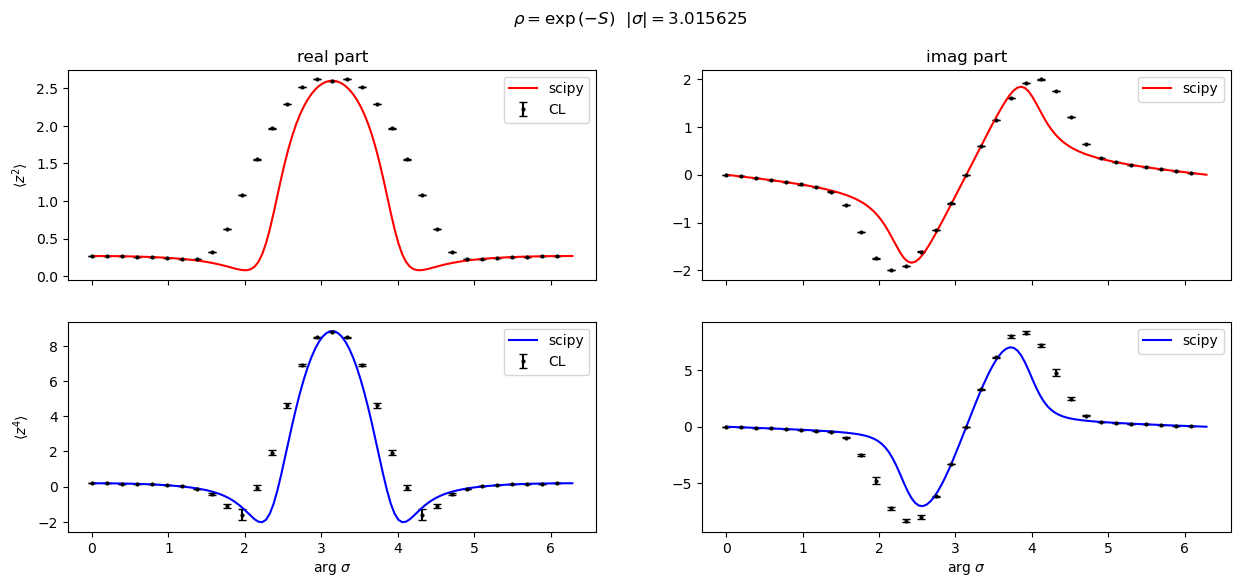

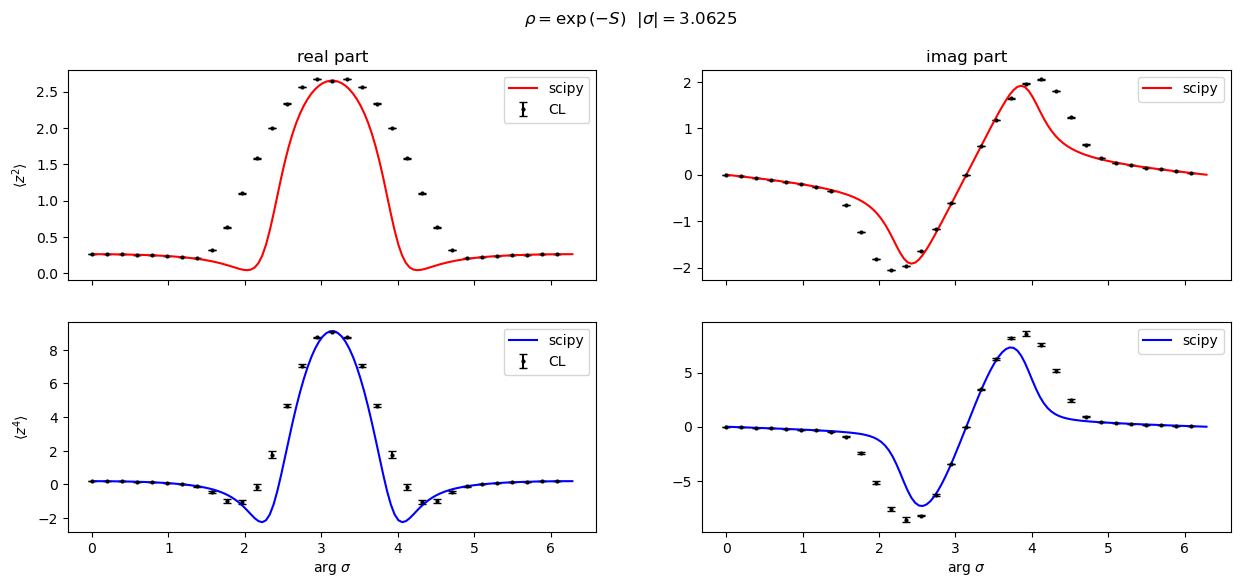

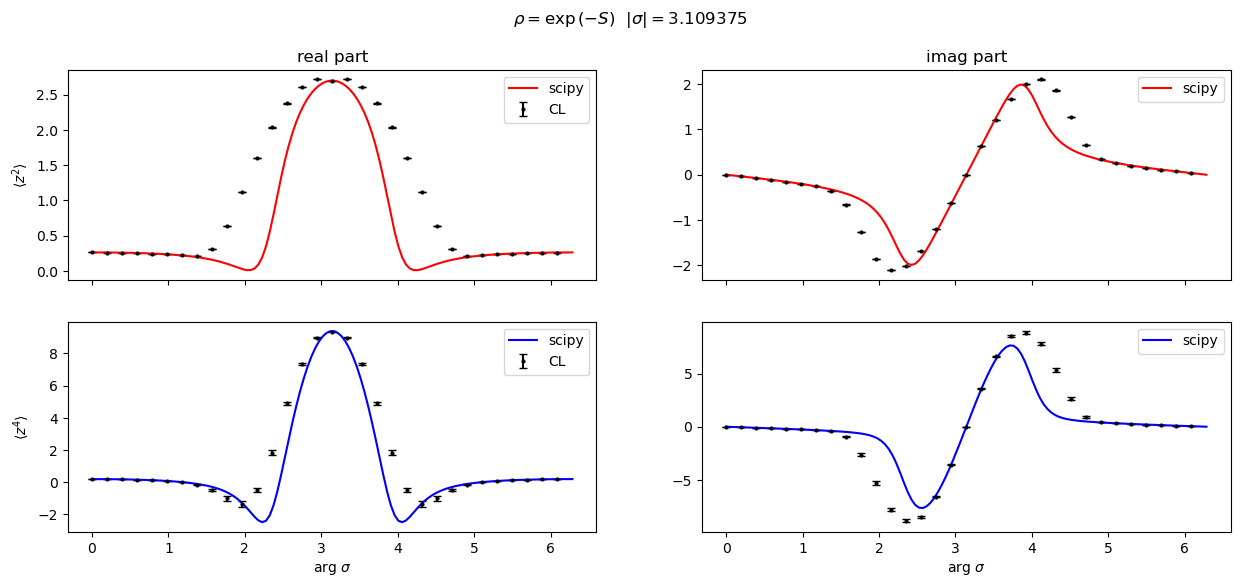

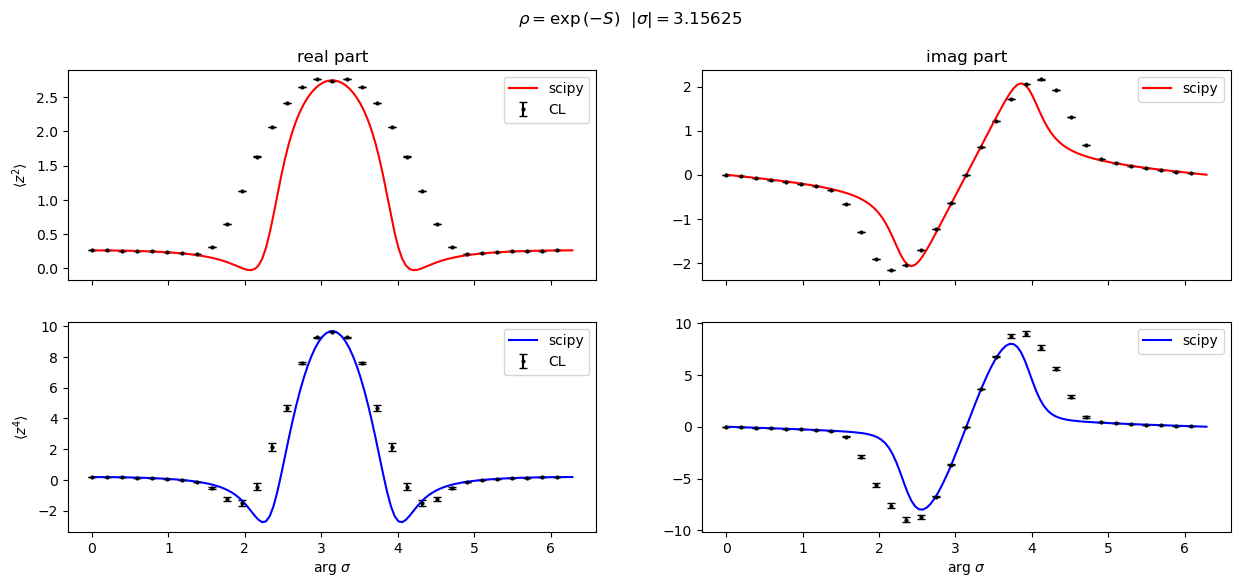

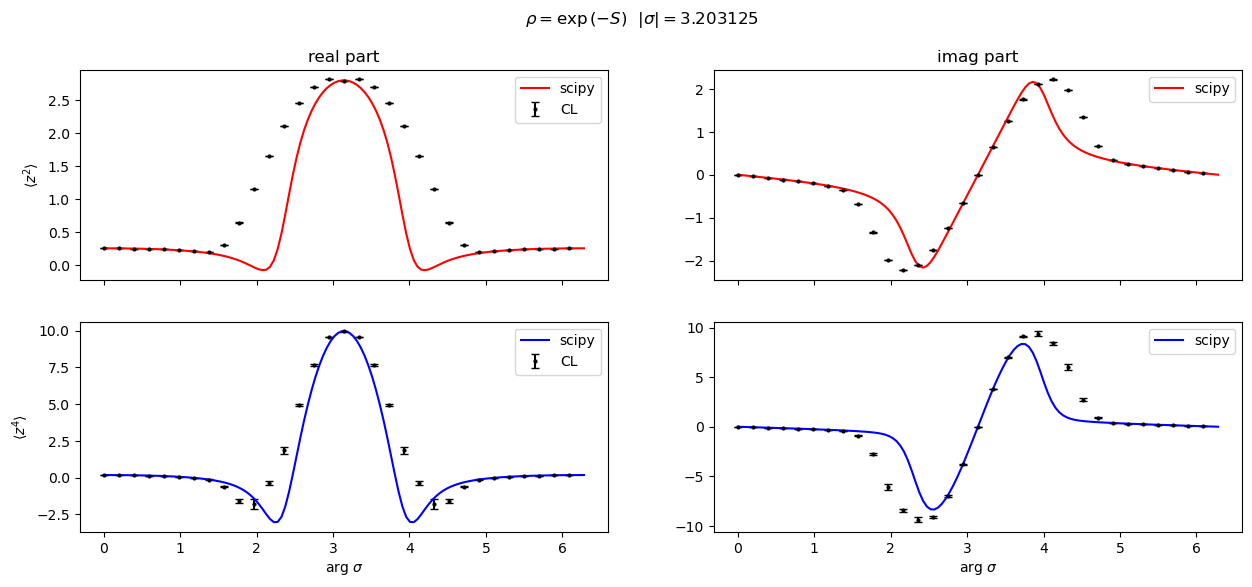

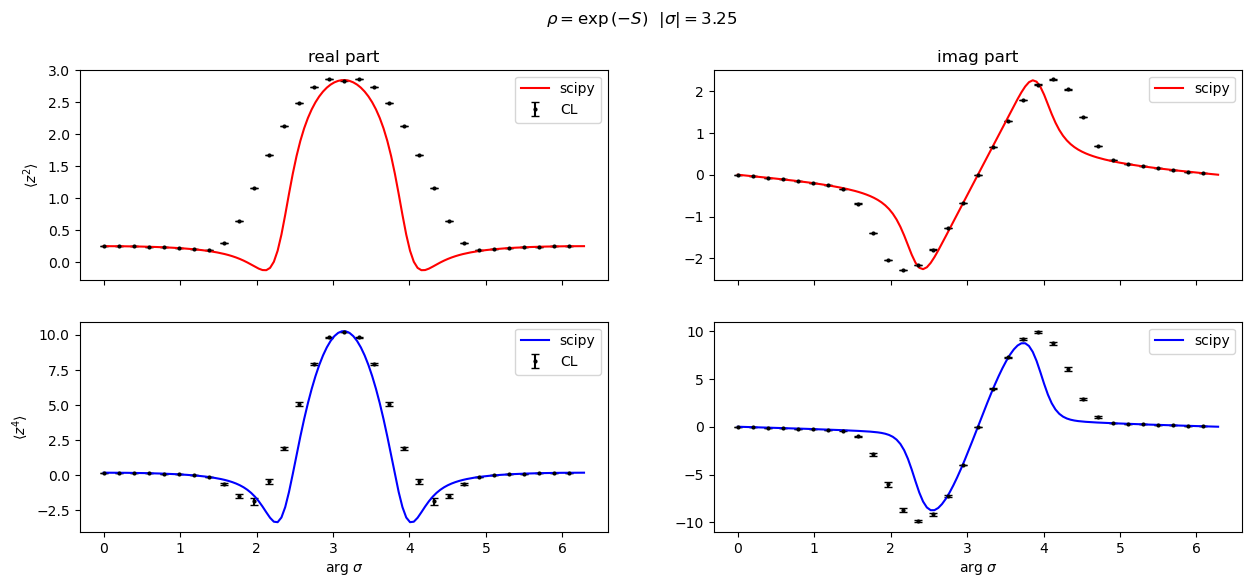

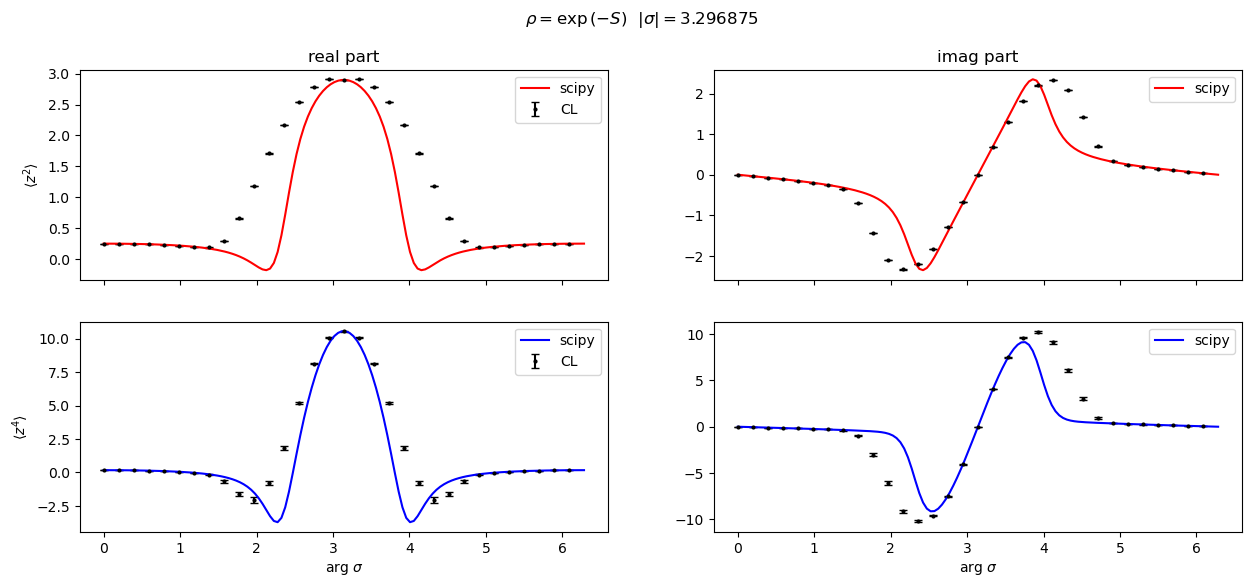

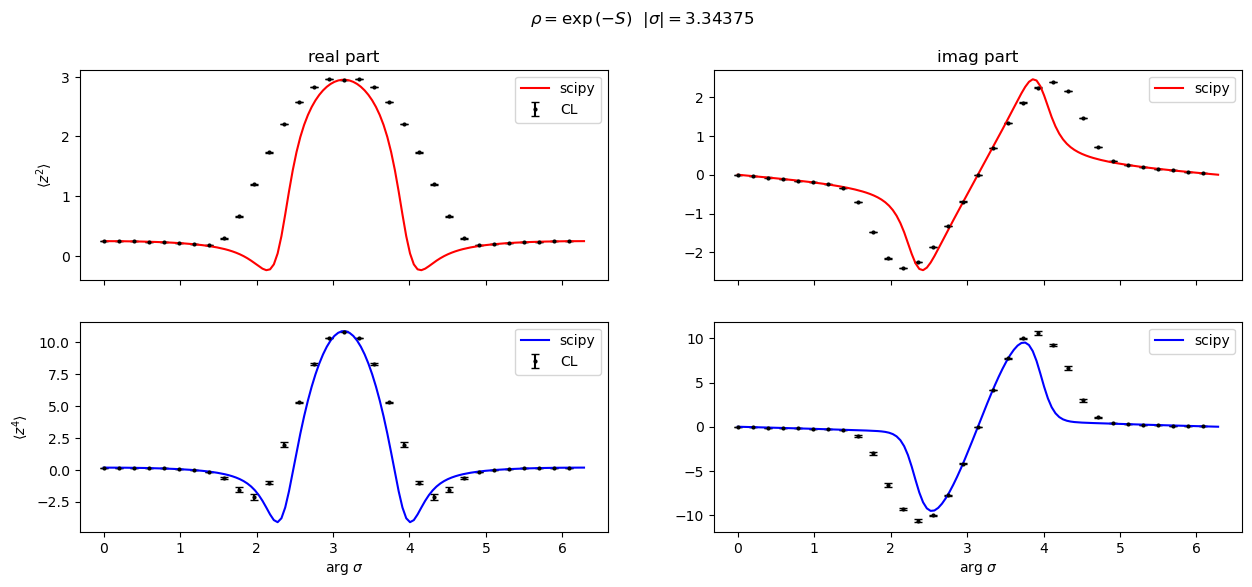

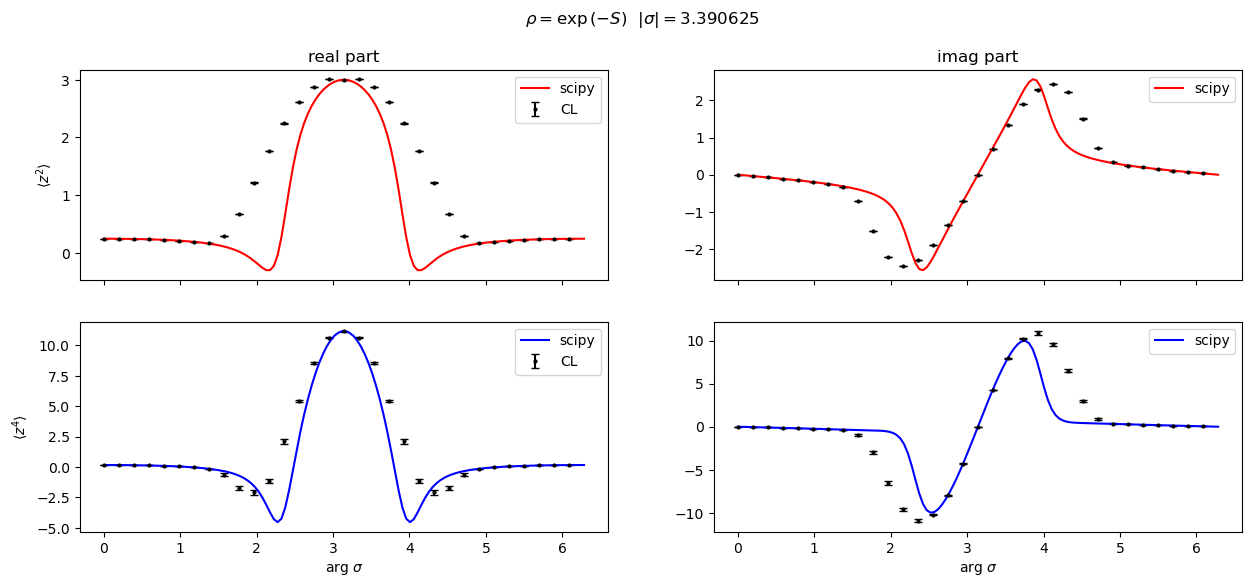

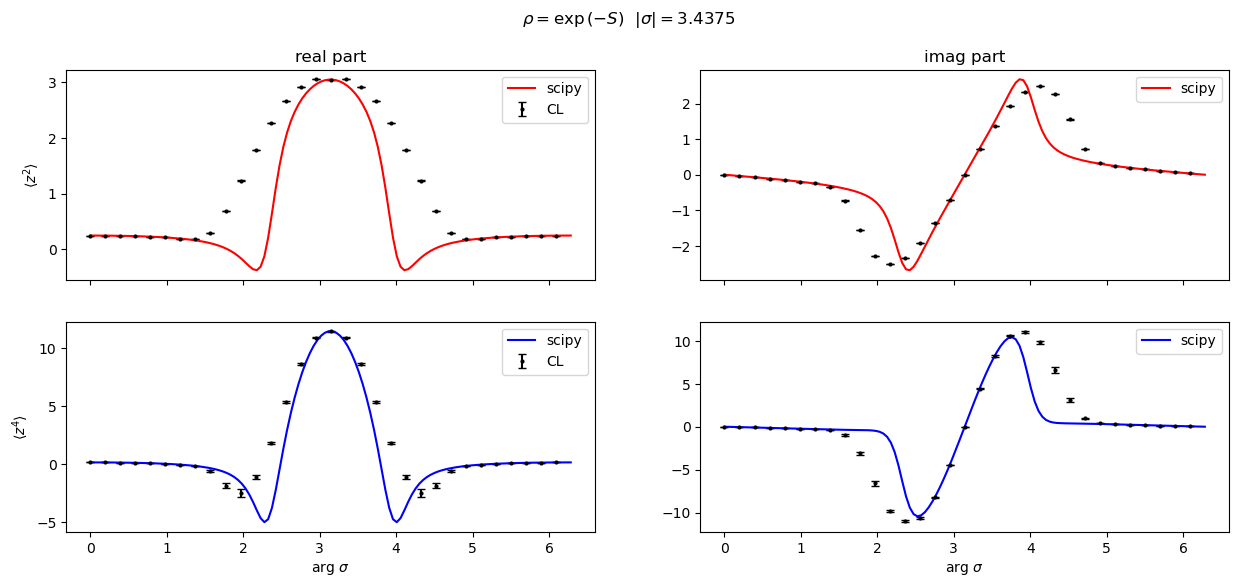

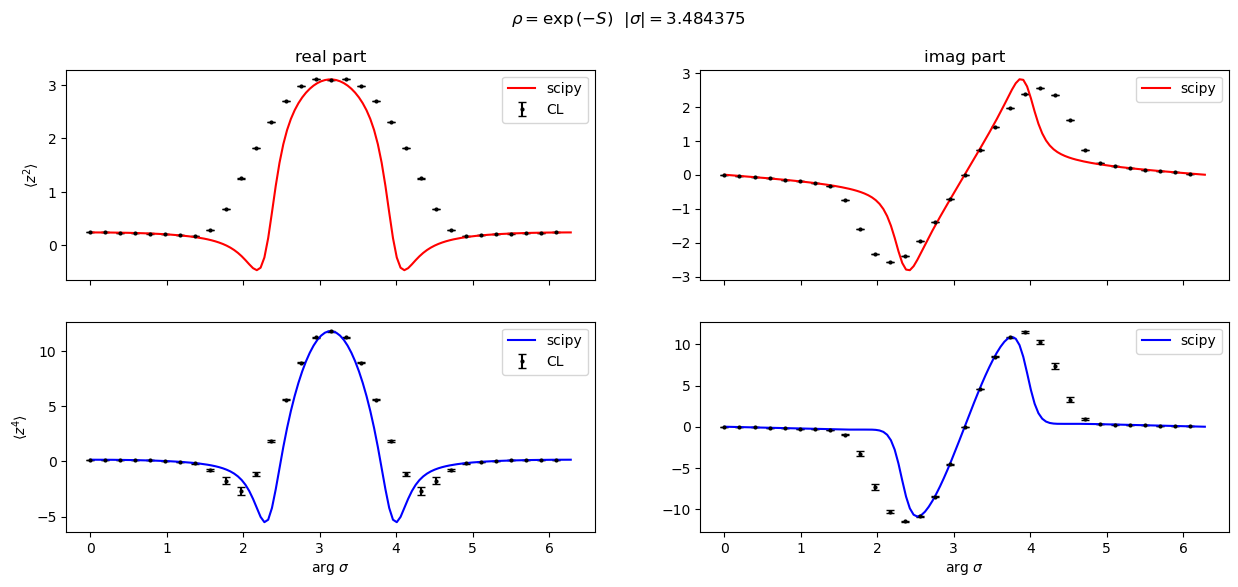

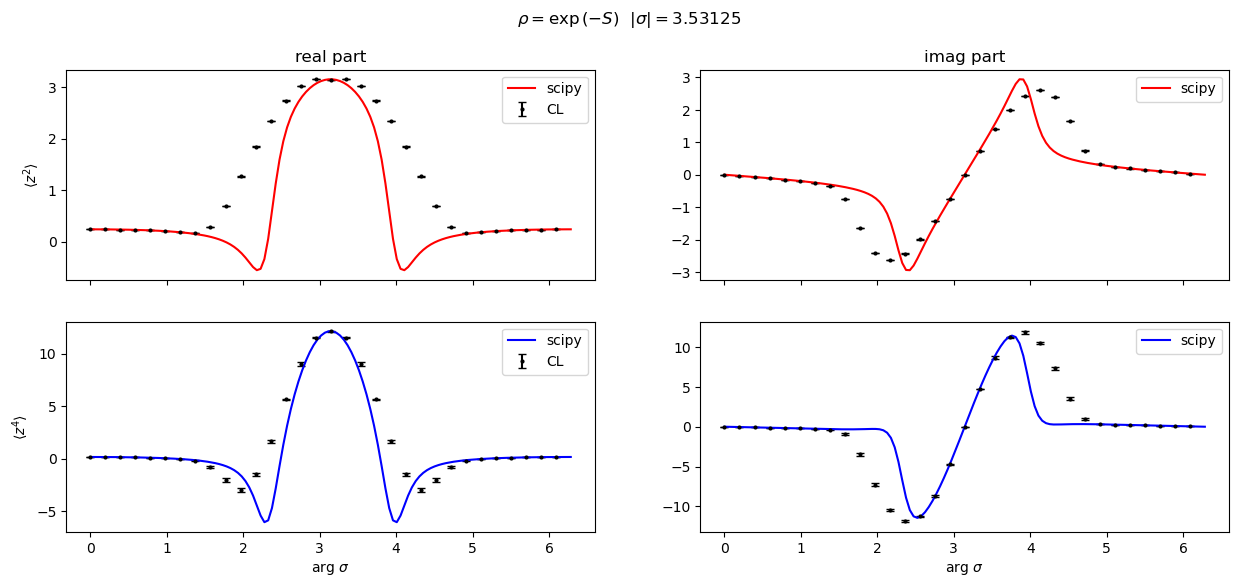

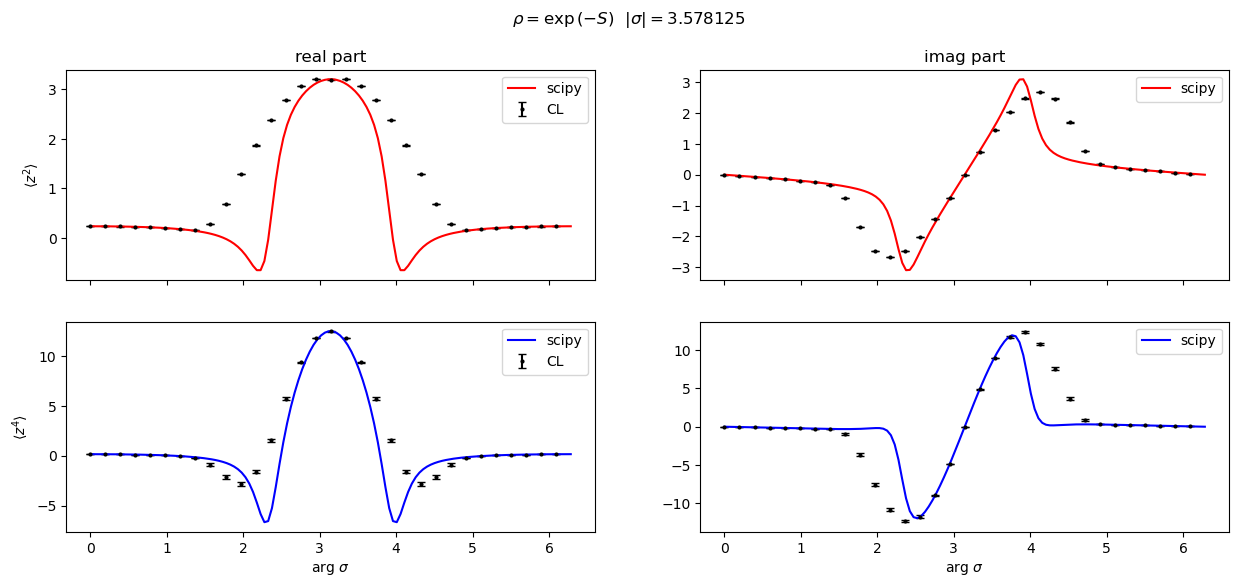

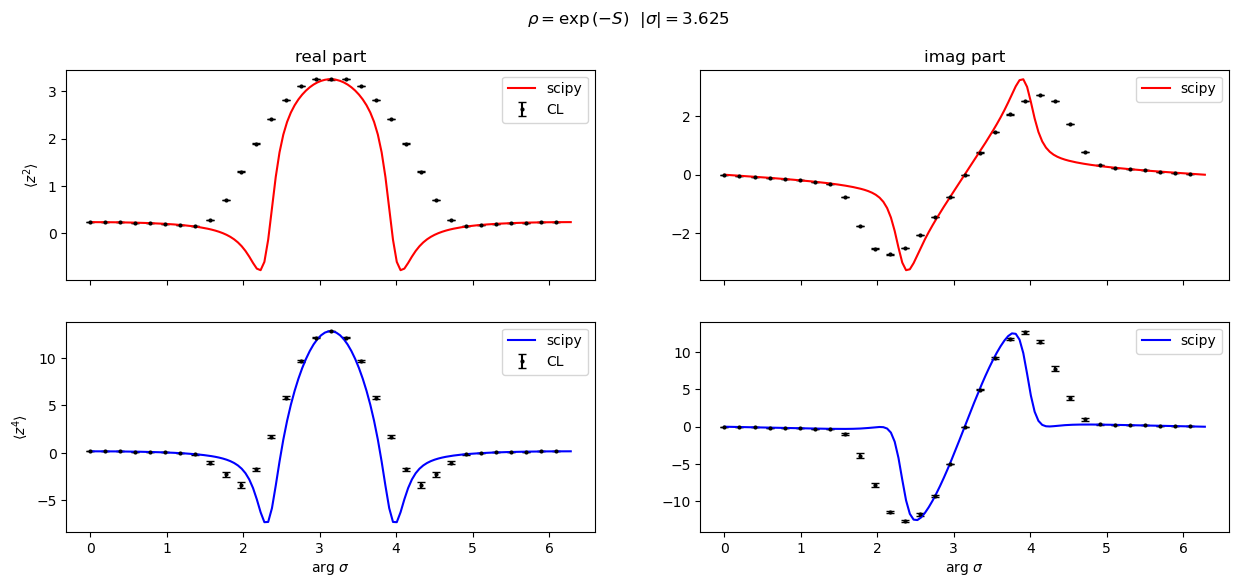

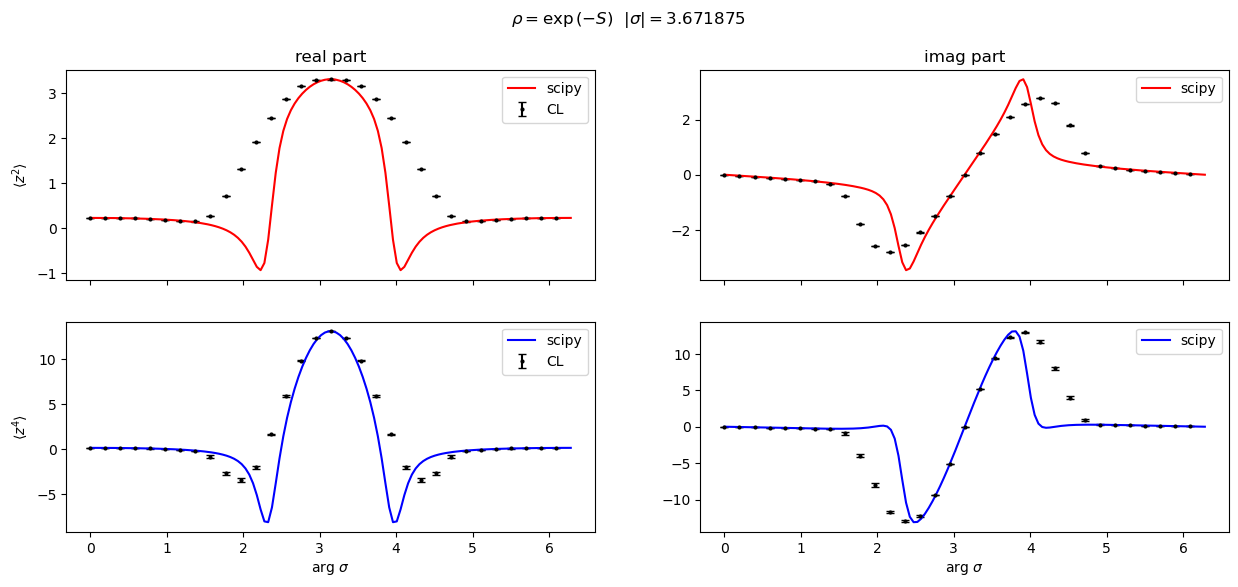

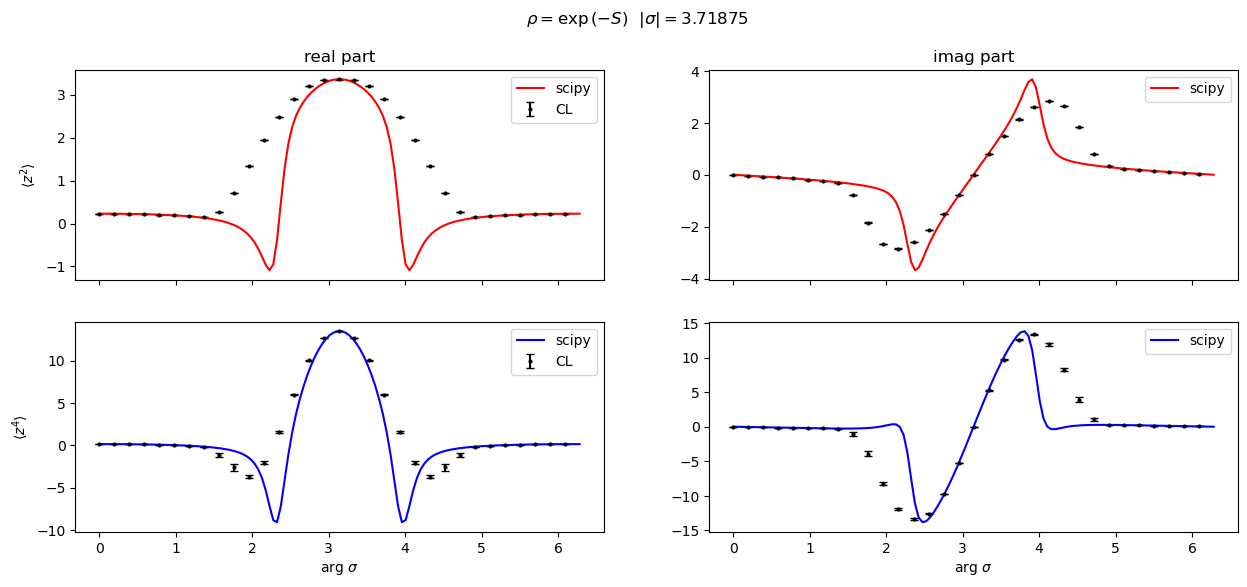

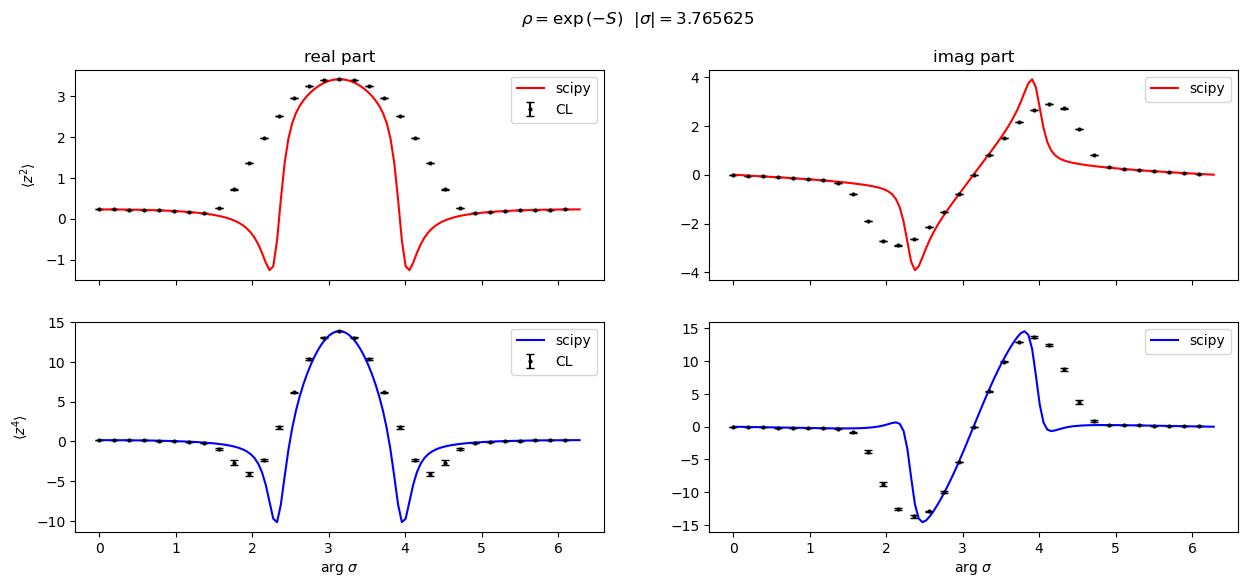

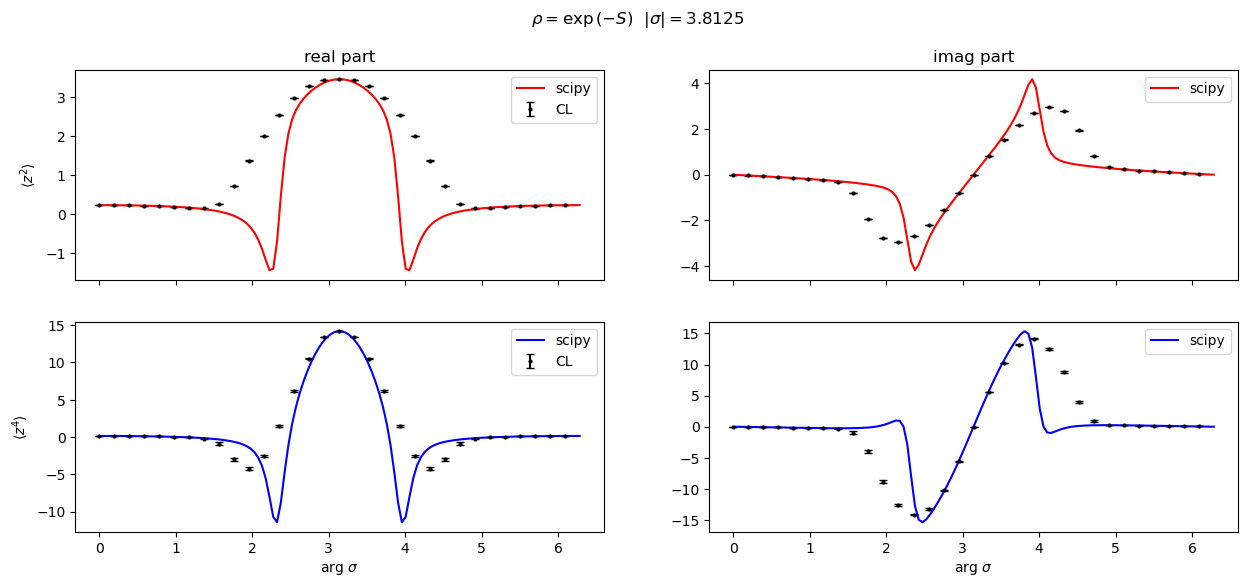

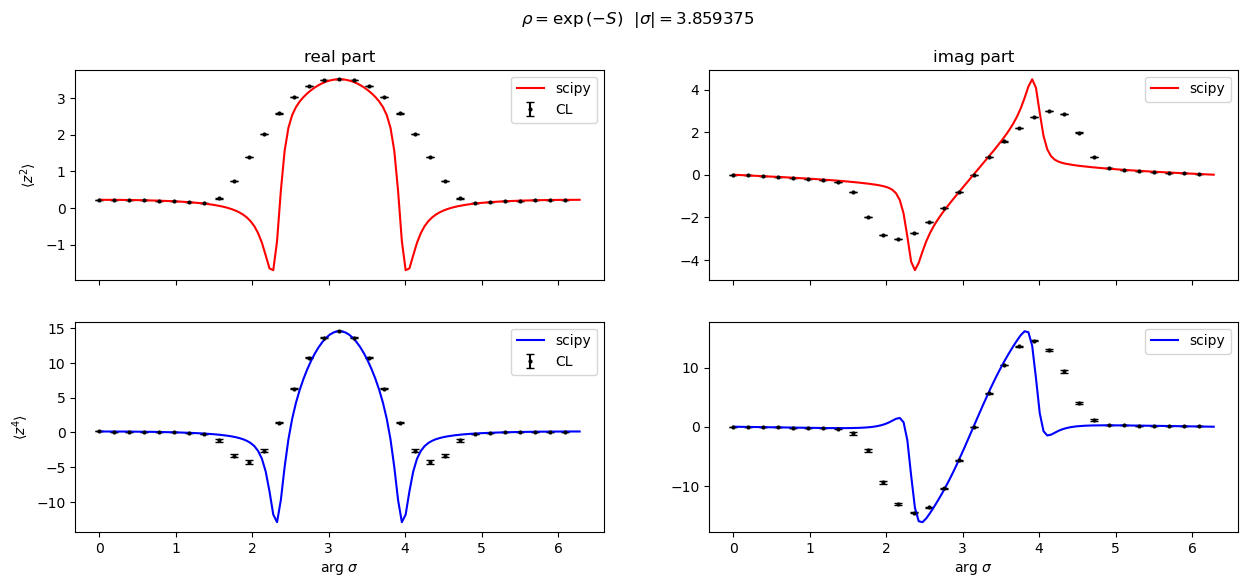

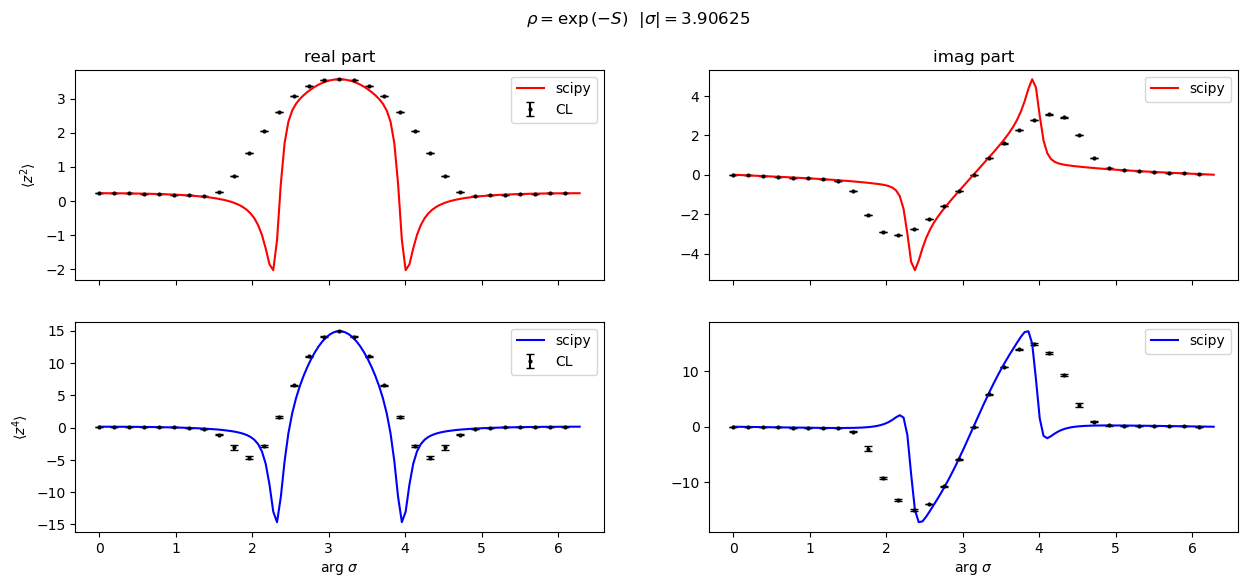

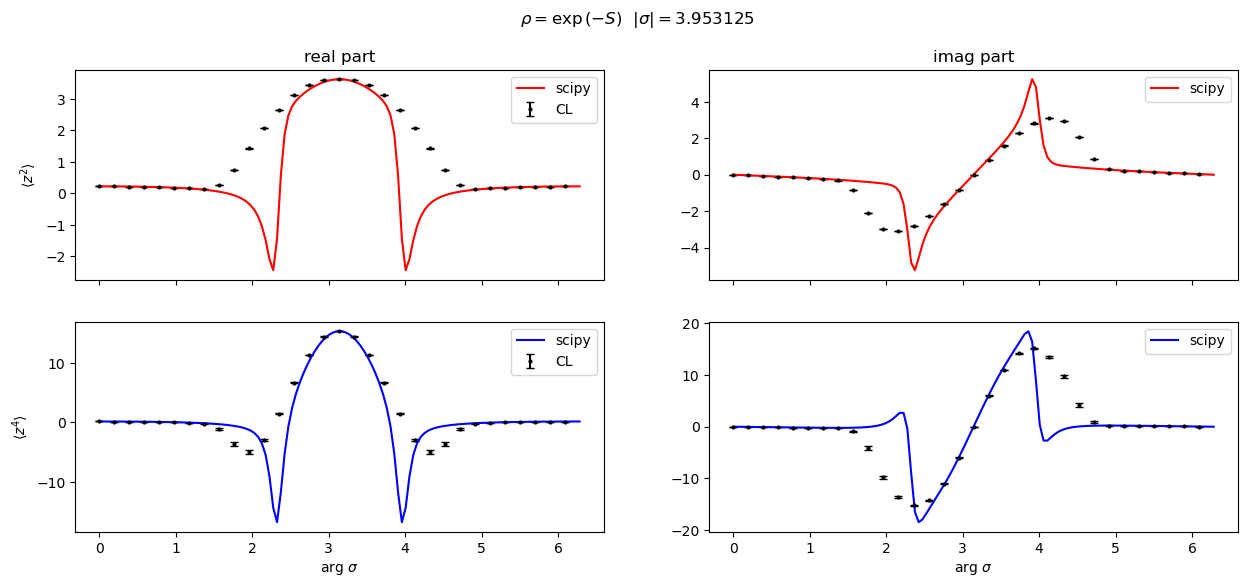

In [9]:
import scienceplots
# plt.style.use('science')

for sigma_abs, sigma_abs_group in df.groupby("sigma_abs"):
    if True:
        fig, axes = plt.subplots(2, 2, figsize=(15, 6), sharex = True) 
        axes = axes.flatten()
        fig.suptitle(rf"$\rho = \exp{{(-S)}}$  $|\sigma| = {{{sigma_abs}}}$")

        sigma_phase_ana = np.linspace(0, 2*np.pi, 128)
        sigma_ana = sigma_abs * np.exp(1j*sigma_phase_ana)

        axes[0].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["2_moment_mean_real"],yerr=sigma_abs_group["2_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2, label = "CL")
        axes[2].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["4_moment_mean_real"],yerr=sigma_abs_group["4_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2, label = "CL")
        axes[1].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["2_moment_mean_imag"],yerr=sigma_abs_group["2_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2)
        axes[3].errorbar(sigma_abs_group["sigma_phase"], sigma_abs_group["4_moment_mean_imag"],yerr=sigma_abs_group["4_moment_sem"], fmt='o',color='black', capsize=3 ,markersize=2)
        
        ana = n_moment_expval_unmod(2, sigma_ana, 1)
        axes[0].plot(sigma_phase_ana, np.real(ana), color = "red", label = "scipy")
        axes[1].plot(sigma_phase_ana, np.imag(ana), color = "red", label = "scipy")

        ana = n_moment_expval_unmod(4, sigma_ana, 1)
        axes[2].plot(sigma_phase_ana, np.real(ana), color = "blue", label = "scipy")
        axes[3].plot(sigma_phase_ana, np.imag(ana), color = "blue", label = "scipy")

        axes[0].set_title("real part")
        axes[1].set_title("imag part")

        axes[0].legend()
        axes[1].legend()
        axes[2].legend()
        axes[3].legend()

        axes[2].set_xlabel(rf"arg $\sigma$")
        axes[3].set_xlabel(rf"arg $\sigma$")
        axes[0].set_ylabel(rf"$\langle z^2 \rangle$")
        axes[2].set_ylabel(rf"$\langle z^4 \rangle$")
        print(f"{sigma_abs}: max imag rel err: {sigma_abs_group['2_moment_mean_imag_clerror'].max()}")
        